<center><font size=6>SuperKart Deployment</font></center>

# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [1]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.3 huggingface_hub==0.30.1  Werkzeug==2.2.2 flask==2.2.2 gunicorn==20.1.0 streamlit==1.43.2 -q

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libraries different ensemble classifiers
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline, Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# to be used as common seed through-out the analysis
RS=42

# Library to ignore warnings
import warnings
warnings.filterwarnings('ignore')

# **Loading the dataset**

In [2]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Load the data
# dataset path
data_path = '/content/drive/MyDrive/AI & ML Course/7. Model Deployment/Project/SuperKart.csv'

# Read the data
superkart_df = pd.read_csv(data_path)

# Create a copy of data
dataset = superkart_df.copy()

# **Data Overview**

In [4]:
# Display the first 5 rows in the dataset
dataset.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [5]:
# Display the last 5 rows in the dataset
dataset.tail()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


In [6]:
# Check the shape of the data
dataset.shape

(8763, 12)

Observation
* A total of 8763 records and 12 features were present in the data.

In [7]:
# Check the datatypes
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


Observations
* The dataset has 5 numerical variables and the remaining 7 were categorical variables.
* Product_Id, Product_Sugar_Content, Product_Type, Store_Id, Store_Size, Store_Location_City_Type and Store_Type were categorical variables.
* Product_Weight, Product_Allocated_Area, Product_MRP, Store_Establishment_Year, Product_Store_Sales_Total were numerical variables.

In [8]:
# Checking for duplicate values
dataset.duplicated().sum()

np.int64(0)

Observation
* There are no duplicate records present in the dataset.

In [9]:
# Checking for null values
dataset.isnull().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


Observation
* There are no missing values in the dataset.

In [10]:
# Satistical summary of numerical features in the dataset
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


Observations
* **Product_Weight**: The minimum and maximum weight of a product is 4 and 22 respectively, and the average is of 12.65.
* **Product_Allocated_Area**: The minimum and maximum allocated area for a product is of 0.004 and 0.298 respectively, while the average allocated area is of 0.0687.
* **Product_MRP**: The minimum and maximum mrp of a product is 31 and 266 respectively, while the mean mrp is of 147.03.
* **Store_Establishment_Year**: The initial store was established during 1987 and the latest store was established during 2009.
* **Product_Store_Sales_Total**:  The minimum and maximum store sales total of a product is 33 and 8000 respectively, while the mean is of 3464.

In [11]:
# Satistical summary of categorical features in the dataset
dataset.describe(include='object').T

,count,unique,top,freq
Product_Id,8763,8763,FD306,1
Product_Sugar_Content,8763,4,Low Sugar,4885
Product_Type,8763,16,Fruits and Vegetables,1249
Store_Id,8763,4,OUT004,4676
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676


Observations
* **Product_Id**: The product id has 8763 unique values, which is equal to the total records in the dataset, which can be dropped for further analysis.
* **Product_Sugar_Content**: There are 4 unique values in product sugar content, in the data description it has been explained there are 3 unique values, need to perform detailed analysis to check further. The top record is Low Sugar which has almost 4885 records.
* **Product_Type**: There are 16 unique product types, where Fruits and Vegetables is the top record, occured almost 1249 times.
* **Store_Id**: A total of 4 stores were present, OUT004 is the top store, occured almost 4676 times in the dataset.
* **Store_Size**:  There almost 3 different store sizes, where Medium type store size is the most frequently occured record i.e., almost 6025 times in the dataset.
* **Store_Location_City_Type**:  There 3 different store location city types, where Tier 2 type is most frequently occured record i.e., almost 6262 times in the dataset.
* **Store_Type**:  There 4 different store types, where Supermarket Type2 is most frequently occured record i.e., almost 4676 times in the dataset.

In [12]:
# Check unique records in categorical variable

# List all categorical columns
cat_cols = dataset.select_dtypes(include='object').columns.to_list()

# Print the unique values for each categorical variable
for col in cat_cols:
  print(dataset[col].value_counts())
  print('-'*40)

Product_Id
FD306     1
FD6114    1
FD7839    1
FD5075    1
FD8233    1
         ..
FD1387    1
FD1231    1
FD5276    1
FD8553    1
FD6027    1
Name: count, Length: 8763, dtype: int64
----------------------------------------
Product_Sugar_Content
Low Sugar    4885
Regular      2251
No Sugar     1519
reg           108
Name: count, dtype: int64
----------------------------------------
Product_Type
Fruits and Vegetables    1249
Snack Foods              1149
Frozen Foods              811
Dairy                     796
Household                 740
Baking Goods              716
Canned                    677
Health and Hygiene        628
Meat                      618
Soft Drinks               519
Breads                    200
Hard Drinks               186
Others                    151
Starchy Foods             141
Breakfast                 106
Seafood                    76
Name: count, dtype: int64
----------------------------------------
Store_Id
OUT004    4676
OUT001    1586
OUT003    1349
O

Observations
* **Product_ID**: The product id feature can be dropped, since it unique to every product and will not impact the sales forecast.
* **Product_Sugar_Content**: The product sugar content has 4 unique records, where one unique record is a short form of Regular i.e., reg and it should be converted to Regular.
* **Product_Type**: There are 16 product types, where Fruits and Vegetables has highest number of records i.e., 1249 and Seafood has least number of records i.e., 76.
* **Store_ID**: There are total of 4 stores, where OUT004 has highest number of records i.e., 4676.
* **Store_Size**: There are 3 types of store sizes, where Medium store size has almost 6025 records which is highest, while Small store size has 1152 records which is least.
* **Store_Location_City_Type**: There are 3 types of store location city types, where more number of stores were located in Tier 2 i.e., of 6262, while Tier 3 has least number of stores when compared i.e., of 1152.
* **Store_Type**: There are 4 different types of stores, where Supermarket Type2 is of 4676 which is highest while Food Mart type of stores were least i.e., of 1152.

# **Exploratory Data Analysis (EDA)**

* Product_ID is not considered for further analysis, since it is an unique identifier and not add much importance for forecasting sales.

In [13]:
# Define target variable for forecast
target = 'Product_Store_Sales_Total'
print(f'The target feature in the dataset is: {target}')

# List of numerical variables in the dataset
numeric_feat = dataset.select_dtypes(include='number').columns.drop('Product_Store_Sales_Total').tolist()
print(f'The list of numerical features in the dataset were: {numeric_feat}')

# List of categorical variables in the dataset
categor_feat = dataset.select_dtypes(include='object').columns.drop('Product_Id').tolist()
print(f'The list of categorical features in the dataset were: {categor_feat}')

The target feature in the dataset is: Product_Store_Sales_Total
The list of numerical features in the dataset were: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year']
The list of categorical features in the dataset were: ['Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']


## Univariate Analysis

In [14]:
# Function for histplot and boxplot
def hisplot_boxplot(data, feature, figsize=(12,7), kde=False, bins=None):
  """
  A function to plot histogram and boxplot for the numerical variables
  data: Dataset used for plotting
  feature: An attribute from the dataset
  figsize: size of the plot by default is (12,7)
  kde: Whether to display Kernel Density Estimate (by default it is false)
  bins: Number of bins to display (by default it is None)
  """
  fig, (ax_box, ax_hist) = plt.subplots(
      nrows=2,      # Number of rows to display
      sharex=True,  # Subplots to have same axis
      gridspec_kw={'height_ratios': (0.25, 0.75)},
      figsize=figsize
  )

  # Creating hisplot
  sns.histplot(data=data, x=feature, ax=ax_hist, kde=kde, bins=bins, palette='winter') if bins else sns.histplot(
      data=data, x=feature, ax=ax_hist, kde=kde, palette='winter'
  )
  ax_hist.set_title(f'Histogram for {feature}')

  # Axis line for histogram
  # Mean axis line
  ax_hist.axvline(data[feature].mean(), color='green', linestyle='-')
  # Median axis line
  ax_hist.axvline(data[feature].median(), color='black', linestyle='--')

  # Creating boxplot
  sns.boxplot(data=data, x=feature, ax=ax_box, showmeans=True, color='violet') # Display mean
  ax_box.set_title(f'Boxplot for {feature}')

  plt.show()

In [15]:
# Function for labeled bar plot
def labeled_barplot(data, feature, perc=False, n=None):
  """
  A function to create labeled bar plots for the categorical variables
  data: Dataset used for plotting
  feature: An attribute from the dataset
  perc: Whether to display percentage or not (by default it is false)
  n: display the top features (by default it is None)
  """
  total = len(data[feature])
  count = data[feature].nunique()

  if n is None:
    plt.figure(figsize=(count+1, 5))
  else:
    plt.figure(figsize=(n+1, 5))

  plt.xticks(rotation=90, fontsize=15)

  # Labeled bar plot
  ax = sns.countplot(
      data=data,
      x=feature,
      hue=feature,
      palette='viridis',
      order=data[feature].value_counts().index[:n] # order top n elements in ascending order
  )

  for p in ax.patches:
    if perc == True:
      label = '{:.2f}%'.format((p.get_height()/total)*100)  # Display in percentage, if perc is true
    else:
      label = p.get_height() # Display the count of each feature

    x = p.get_x() + p.get_width()/2  # width of the plot
    y = p.get_height()  # height of the plot

    plt.title(f'Bargraph of {feature}')   # plot title

    plt.annotate(
        label,
        (x, y),
        ha = 'center',
        va = 'center',
        size=12,
        xytext= (0, 5),
        textcoords='offset points'
    )

    plt.legend(loc='upper right', bbox_to_anchor=(1, 1))  # Display legend
  plt.show()

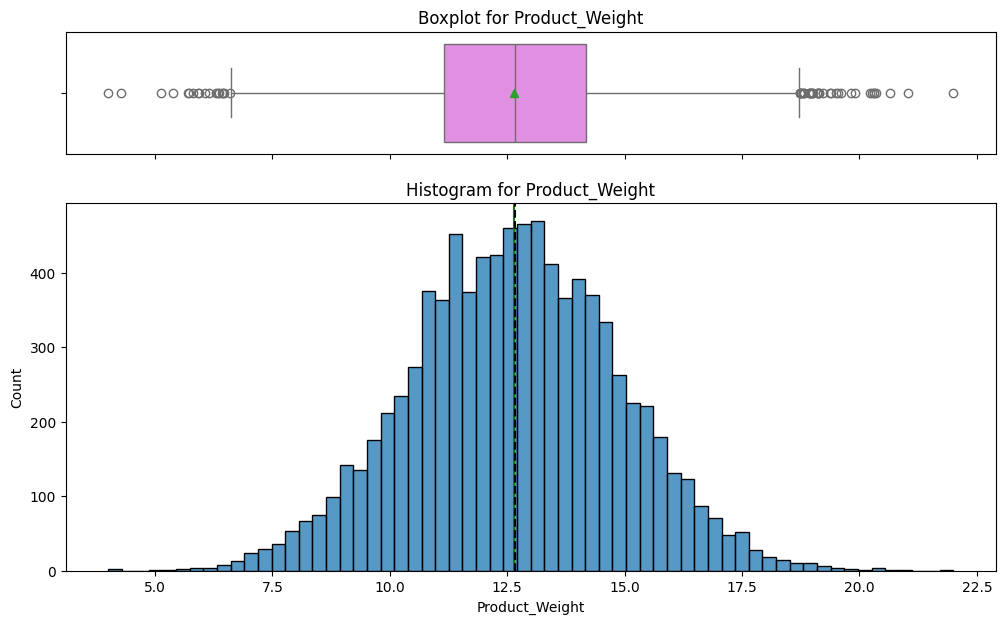

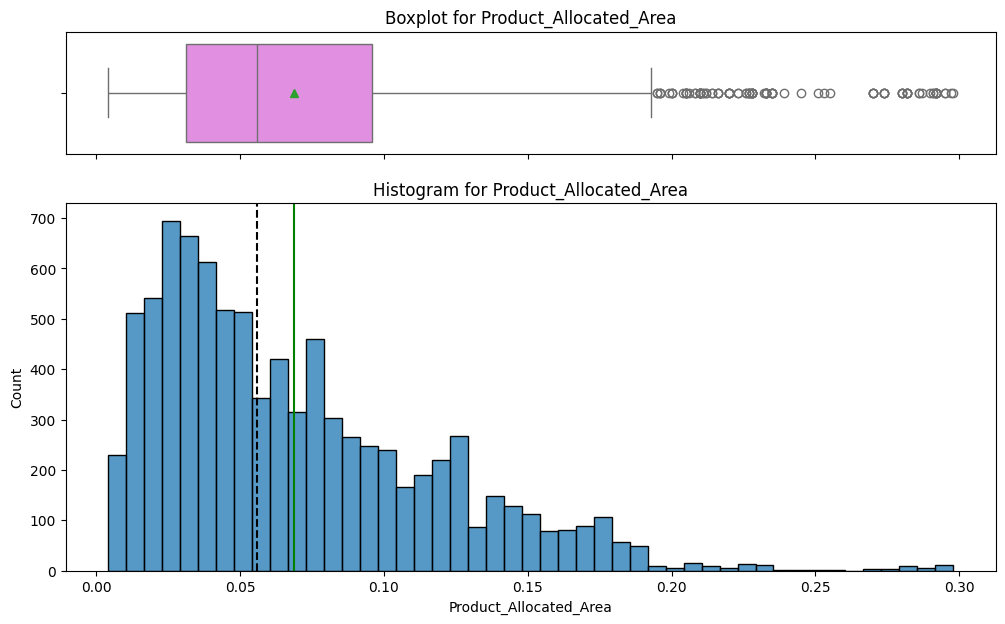

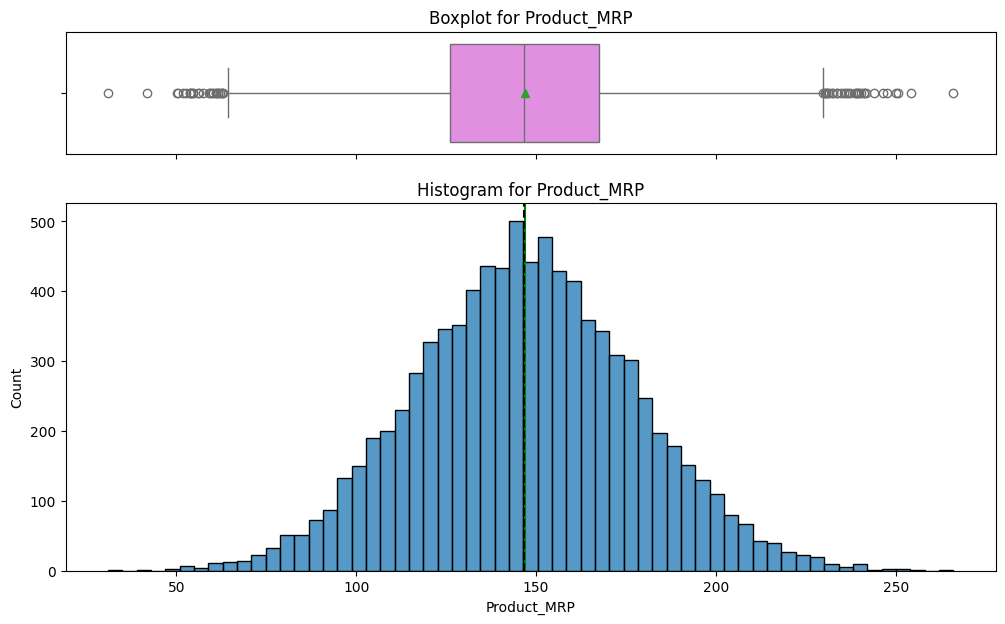

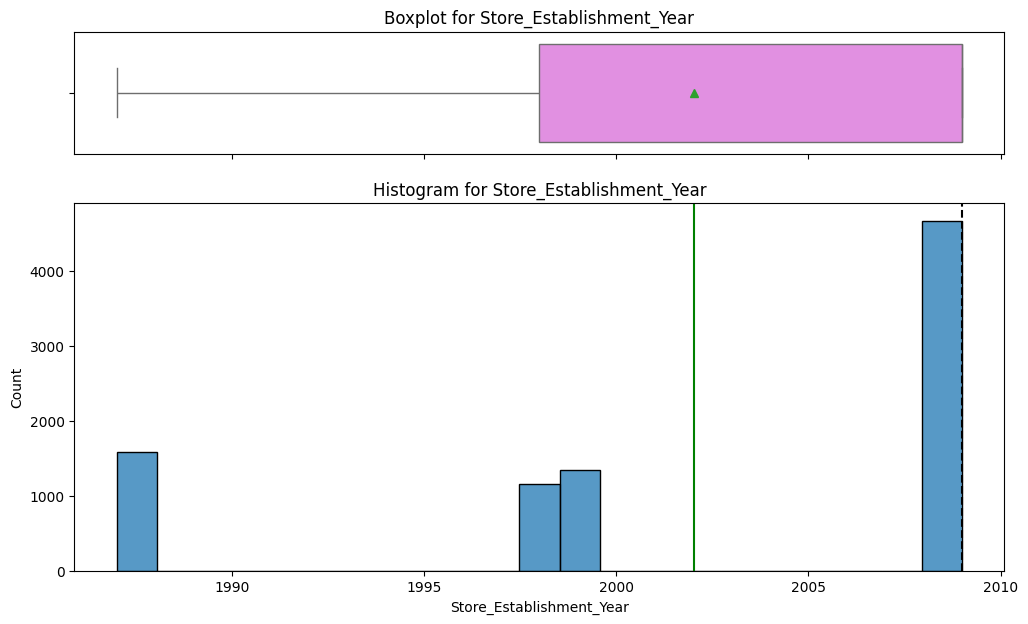

In [16]:
# Plot the numerical features
for num in numeric_feat:
  hisplot_boxplot(data=dataset, feature=num)
  print(' ')

Observations
* **Product_Weight**
    * The product weight attribute is symmetrical, where the mean and median were matching approximately, though the distribution is normal, there are outliers on both the sides of the plot.
    * The mean and median weights of the product is approximately 12.6.
    * The least weight of the product is of approximately 3 and the highest weight of the product is approximately of 22.
    * There are more number of products weighing in-between 7.5 to 17.5.

* **Product_Allocated_Area**
    * The product allocated area attribute is right-skewed, where the mean value is greater than median, the distribution is right-skewed, there are outliers on the right side of the plot.
    * The mean and median values of product allocated area is of approximately 0.06 and 0.052 approximately.
    * The least allocated area of the product is of approximately 0.001 and the highest area allocated for a product is of 0.29.
    * There are more number of products allocated with an area approximately in-between 0.001 to 0.125.

* **Product_MRP**
    * The product mrp attribute is symmetrical, where the mean and median were matching approximately, though the distribution is normal, there are outliers on both the sides of the plot.
    * The mean and median mrp of the product is approximately 145.
    * The least mrp of the product is of approximately 35 and the highest mrp of the product is approximately of 230.
    * There are more number of products having an mrp in-between 100 to 200.

* **Store_Establishment_Year**
    * The establishment year of the store is left skewed, where the median is greater than the mean.
    * The first store was established approximately during the year 1987, where almost 1800 stores were established.
    * The latest store was established during the year 2009, where there are 4700 stores.


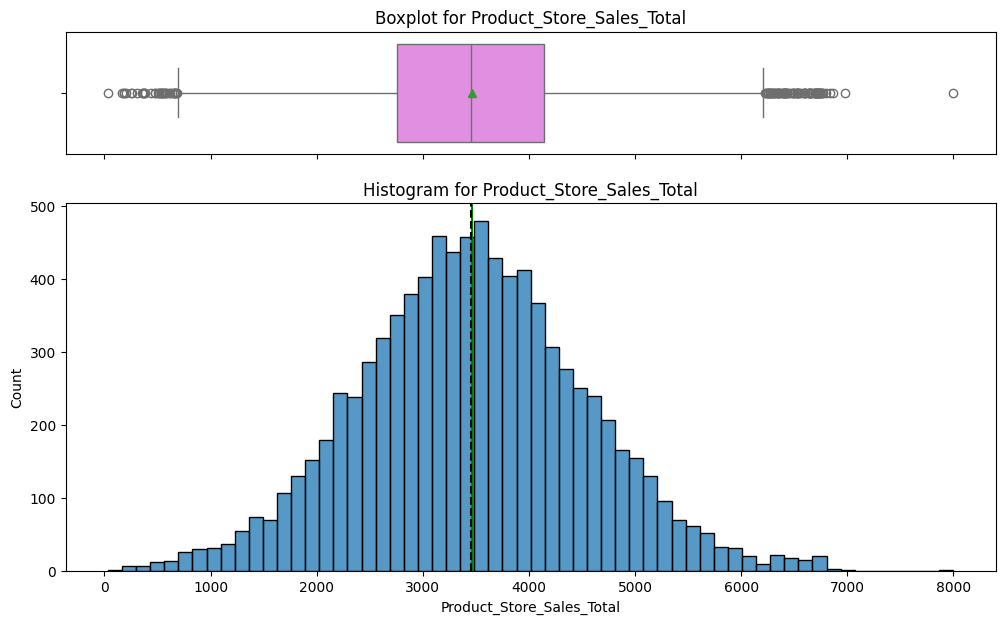

In [17]:
# Plot the Product_Store_Sales_Total
hisplot_boxplot(dataset, target)

Observations
* The product store sales total attribute is symmetrical, where the mean and median were matching approximately, though the distribution is normal, there are outliers on both the sides of the plot.
* The mean and median total sales of the product store is approximately 3,500.
* The least total sales of the product store is of approximately 30 and the highest is approximately of 8,000.
* There are more number of total sales of the product in a prticular store is in-between 2,000 to 5,000.

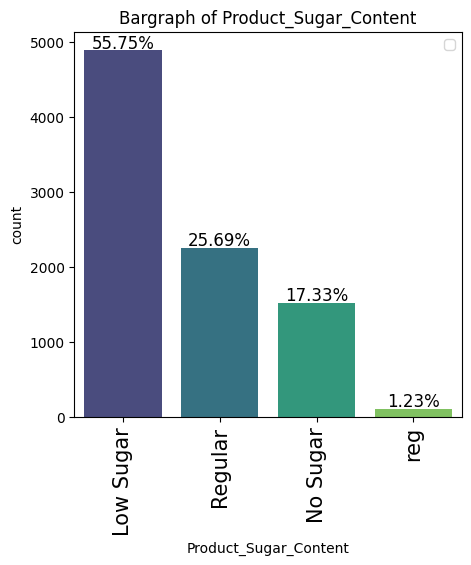

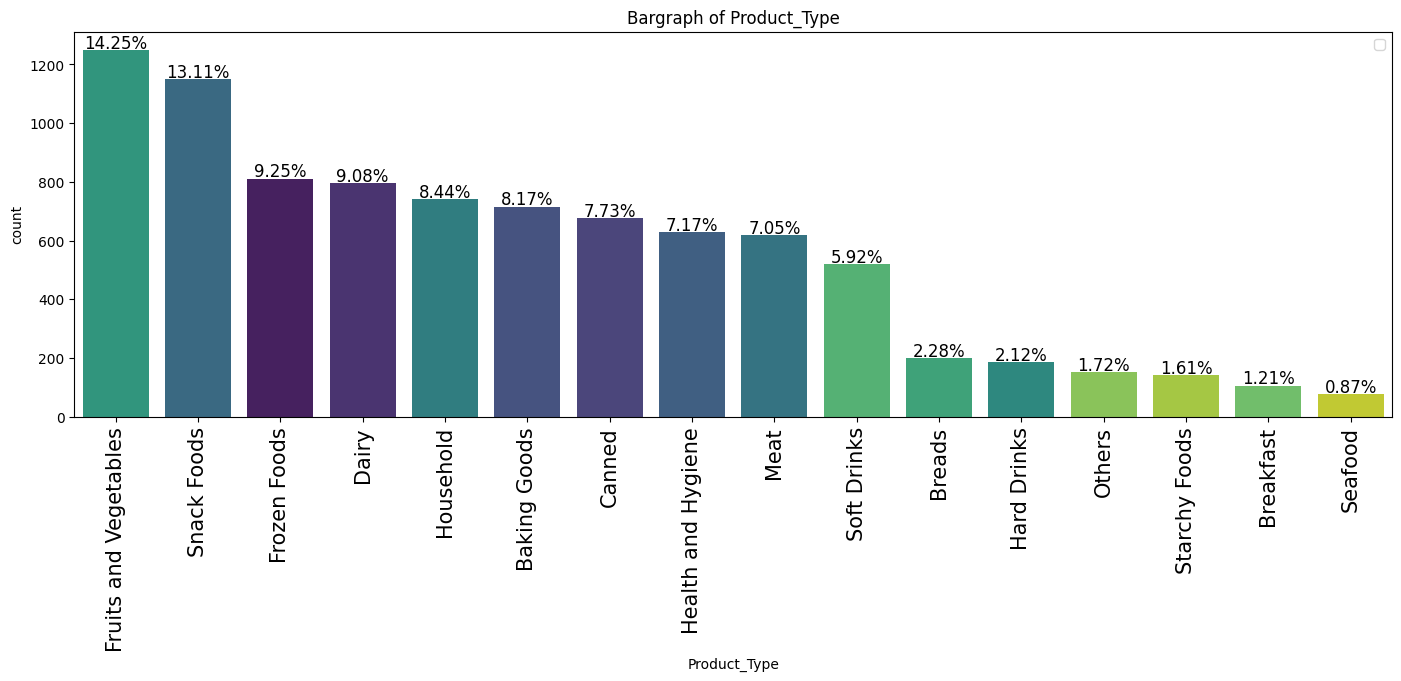

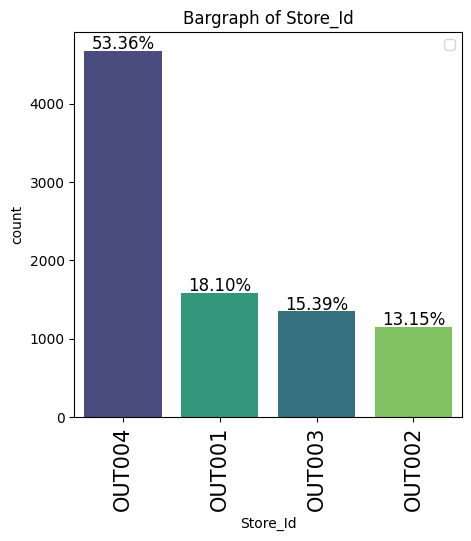

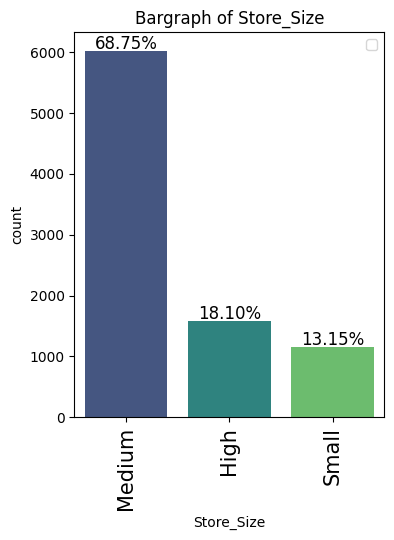

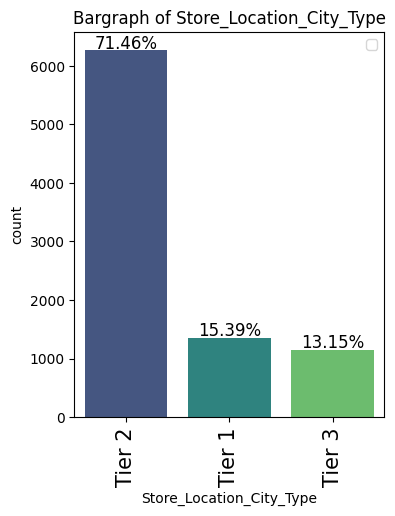

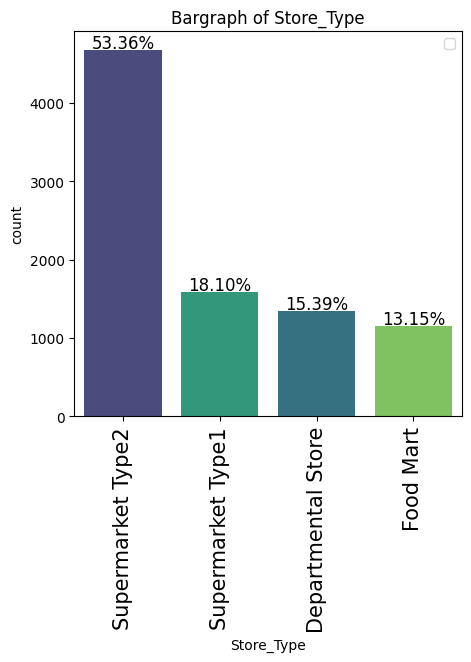

In [18]:
# Plot the categorical features
for cat in categor_feat:
  labeled_barplot(data=dataset, feature=cat, perc=True)
  print(' ')

Observations
* **Product_Sugar_Content**
    * There are more number of products with Low sugar approximately of 55.75%.
    * There are least number of products with no sugar approximately of 17.33%.
    * Approximately 26.92% of products has regular sugar content.

* **Product_Type**
    * There are more number of Fruits and vegetable product type approximately of 14.25%, followed by Snack foods approximately of 13.11%
    * There are almost 8 product types, where each type is in-between 5% to 9.5% i.e., frozen foods of 9.25%, dairy of 9.08%, household of 8.44%, baking goods of 8.17%, canned of 7.73%, health and hygiene of 7.17%, meat of 7.05% and soft drinks of 5.92%
    * There are very least percent of seafood product type i.e., of approximately 0.87%.

* **Store_Id**
    * There are more number of stores with store_id of OUT004 i.e., of 53.36%, followed by OUT001 and OUT003 i.e., of 18.10% and 15.39%.
    * There are least number of stores with store_id of OUT002 i.e., of 13.15%.

* **Store_Size**
    * There are more number of stores with medium size i.e., of 68.75%, followed by high size i.e., of 18.10%.
    * There are least number of stores with small size i.e., of 13.15%.

* **Store_Location_City_Type**
    * There are more number of stores located in tier-2 city i.e., of 71.46%, followed by 15.39% of stores were located in tier-1.
    * There are least number of stores located in tier-3 i.e., of 13.15%.

* **Store_Type**
    * There are more number of supermaket type2 stores i.e., of 53.36%, followed by 18.10% of supermarket type1 stores and 15.39% of departmental stores.
    * There are least number of food mart type stores i.e., of 13.15%.

## Bivariate Analysis

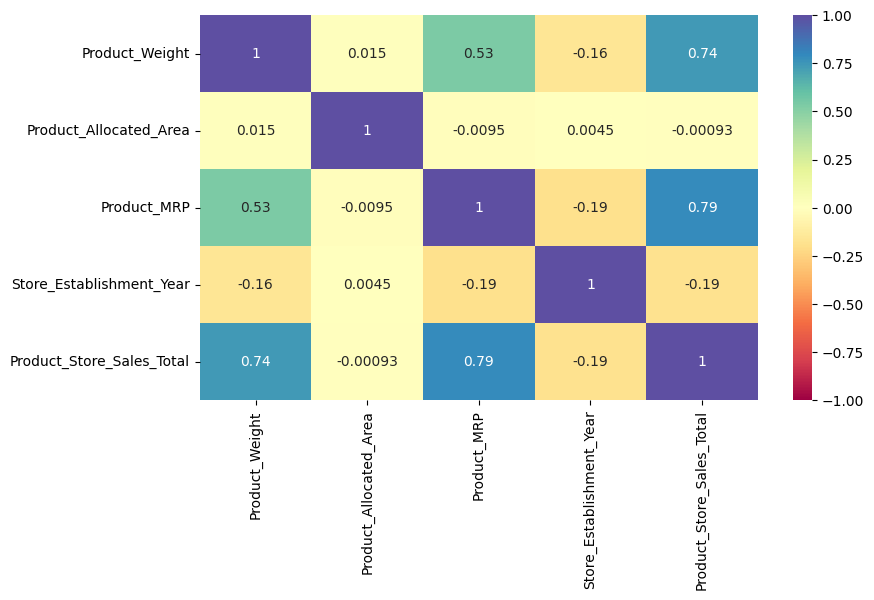

In [19]:
# Calculate correlation matrix for only numeric variables
correlation_matrix = dataset.corr(numeric_only=True)

# Correlation map
plt.figure(figsize=(9,5))
sns.heatmap(correlation_matrix, annot=True ,vmax=1, vmin=-1, cmap='Spectral')
plt.show()

Observations
* The Product_MRP and Product_Store_Sales_Total attributes were highly correlated i.e., of 0.79.
* The Product_Weight and Product_Store_Sales_Total attributes were correlated i.e., of 0.74.
* The Product_MRP and Product_Weight attributes were also correlated i.e., of 0.53.
* The Product_Store_Sales_Total and Product_Allocated_Area attributes were least correlated i.e., of -0.00093.

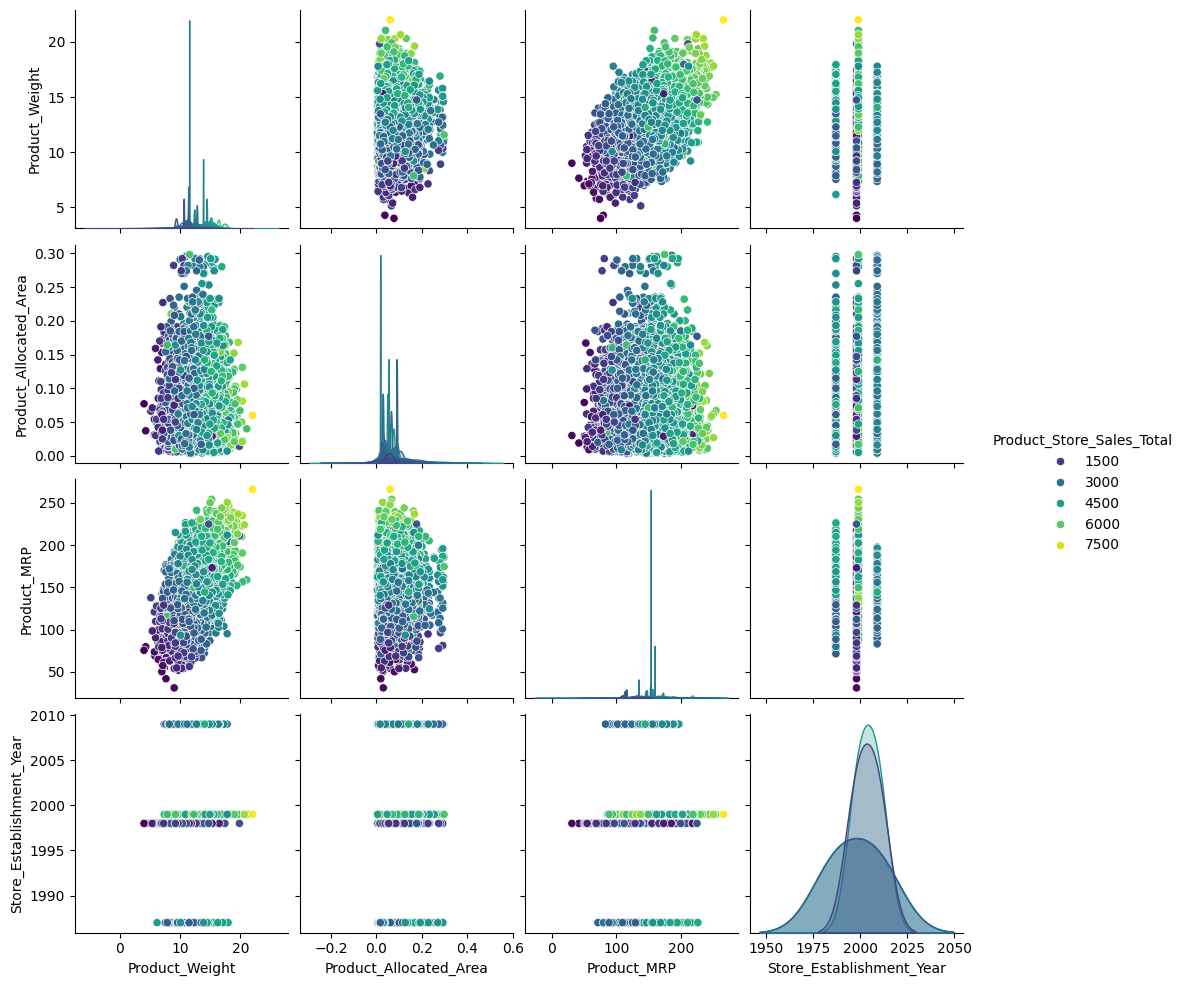

In [20]:
# Pairplot between all the numerical variables with hue as product store sales total
sns.pairplot(dataset, hue=target, palette='viridis')
plt.show()

Observations
* The Product_Weight between 5 to 15 and Product_MRP between 10 to 150 having total revenue generated by the sale of a particular product in a particular store is between 1,500 to 3,000. Also there seems to be some positive correlation i.e., with the increase in Product_Weight the Product_MRP also increases.
* The Product_Weight between 5 to 10 and Product_Allocated_Area between 0.002 to 0.3 having total revenue generated by the sale of a particular product in a particular store is approximately of 1,500.
* The Product_Weight between 10 to 20 and Product_Allocated_Area between 0.002 to 0.3 having total revenue generated by the sale of a particular product in a particular store is between 3,000 to 6,000.
* The Product_Allocated_Area between 0.001 to 0.3 and Product_MRP below 100 having total revenue generated by the sale of a particular product in a particular store is approximately of 1,500.
* The Product_Allocated_Area between 0.001 to 0.3 and Product_MRP greater than 100 having total revenue generated by the sale of a particular product in a particular store is greater than of 3,000.


In [21]:
# Function to create box plot for comparision between dependent and independent variables
def comparision_box_plot(data, predictor):
  """
  A function for comparing plot between each category in a categorical variable and target variable
  data: A dataframe used for analysis
  predictor: Independent variable (categorical)
  target: dependent variable
  """
  plt.figure(figsize=(7, 5))
  sns.boxplot(data=data, x=predictor, y=target) # boxplot between dependent and independent variable
  plt.title(f'{predictor} vs {target}')
  plt.xticks(rotation=90)
  plt.show()

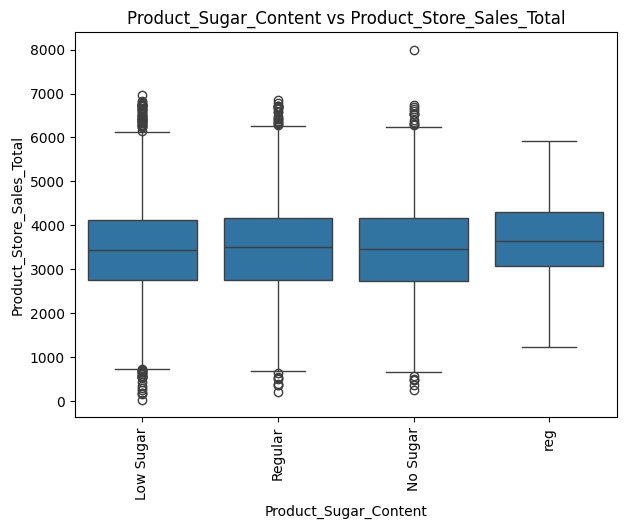

In [22]:
# Plotting between product_sugar_content vs product_store_sales_total
comparision_box_plot(dataset, 'Product_Sugar_Content')

Observations
* Product with the 'Regular' sugar content is having highest median total revenue generated by the sale of a particular product in a particular store i.e., of 3,600 approximately.
* Product with the 'Low' and 'No' sugar content is having almost equal median total revenue generated by the sale of a particular product in a particular store i.e., of 3,400 approximately.

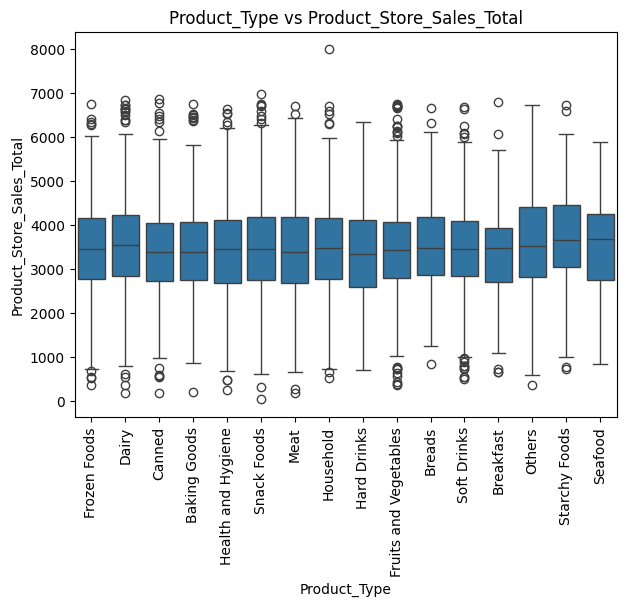

In [23]:
# Plotting between product_type vs product_store_sales_total
comparision_box_plot(dataset, 'Product_Type')

Observations
* The median total revenue generated by the sale of a particular product in a particular store for all product types were ranging between 3,500 to 3,800 approximately.
* 'Starchy Foods' and 'Seafood' product type were having almost equal and highest median total revenue generated by the sale of a particular product in a particular store i.e., of 3,800 approximately.
* Hard Drinks' product type is having almost lowest median total revenue generated by the sale of a particular product in a particular store i.e., of 3,500 approximately.

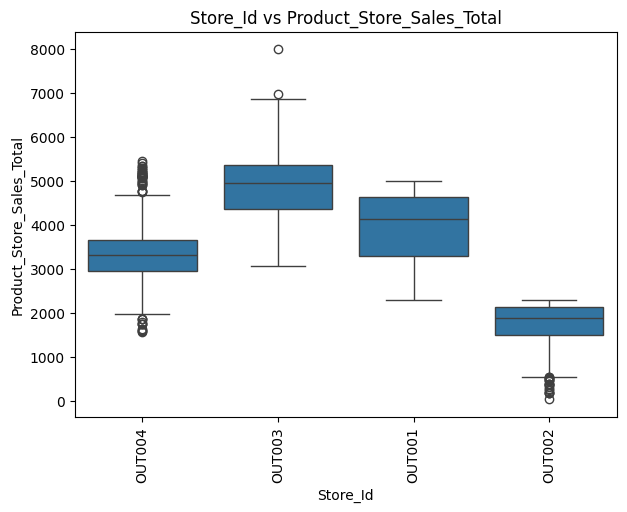

In [24]:
# Plotting between store_id vs product_store_sales_total
comparision_box_plot(dataset, 'Store_Id')

Observations
* The store with an id of 'OUT003' is having highest median total revenue generated by the sale of a particular product in a particular store i.e., of 5,000 approximately.
* The store with an id of 'OUT002' is having lowest median total revenue generated by the sale of a particular product in a particular store i.e., of 1,800 approximately.

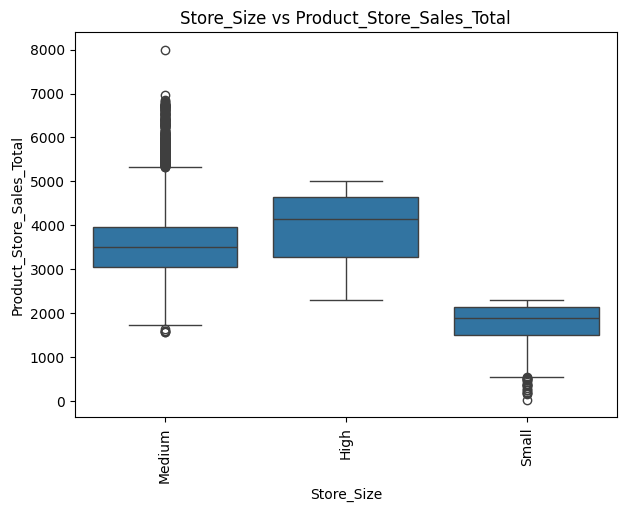

In [25]:
# Plotting between store_size vs product_store_sales_total
comparision_box_plot(dataset, 'Store_Size')

Observations
* The store of 'High' size is having highest median total revenue generated by the sale of a particular product in a particular store i.e., of 4,200 approximately.
* The store of 'Small' size is having lowest median total revenue generated by the sale of a particular product in a particular store i.e., of 1,800 approximately.

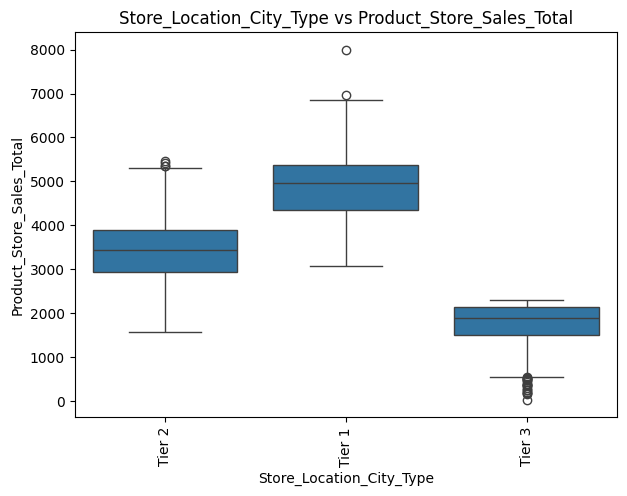

In [26]:
# Plotting between store_location vs product_store_sales_total
comparision_box_plot(dataset, 'Store_Location_City_Type')

Observations
* The stores located in 'Tier-1' cities were having highest median total revenue generated by the sale of a particular product in a particular store i.e., of 4,900 approximately.
* The stores located in 'Tier-3' cities were having lowest median total revenue generated by the sale of a particular product in a particular store i.e., of 1,800 approximately.

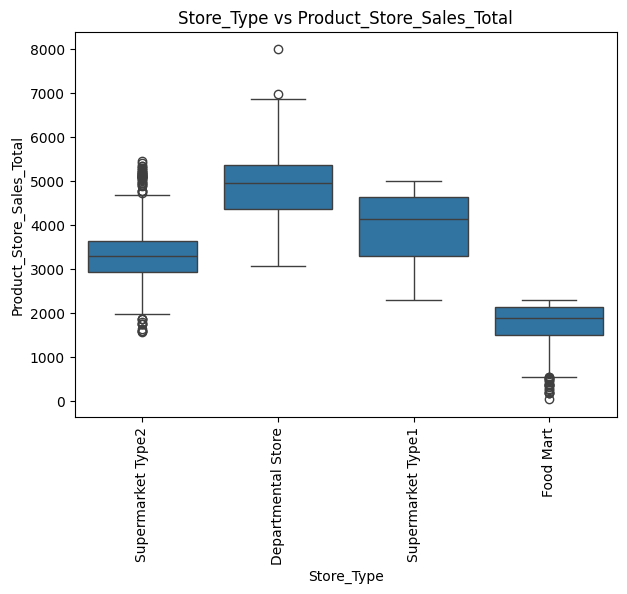

In [27]:
# Plotting between store_type vs product_store_sales_total
comparision_box_plot(dataset, 'Store_Type')

Observations
* The 'Departmental store' type is having highest median total revenue generated by the sale of a particular product in a particular store i.e., of 5,000 approximately.
* The 'Food Mart' type is having lowest median total revenue generated by the sale of a particular product in a particular store i.e., of 1,900 approximately.

In [28]:
# bar graph between categorical variable and total revenue generated by the sale of particular product in a particular store
def bargraph_groupby_category(feature):
  """
  Plotting the histogram between categorical variable and total revenue generated by the sale of particular product in particualar store
  feature: Categorical variable
  """
  # Grouping the categorical record and taking the sum of product_store_sales_total
  cat_groupby = dataset.groupby(feature)[target].sum().reset_index()

  # Sorting the revenue for a particular category in descending order
  revenue_sorted =cat_groupby.sort_values(by=target, ascending=False)

  # Highest category and it's respective revenue total
  top_category = revenue_sorted.iloc[0, 0]
  revenue_total = revenue_sorted.iloc[0, 1]
  print(f'In {feature} the most contributing record for the revenue is {top_category}')
  print(f'The total revenue generated by {top_category} is {revenue_total:.2f}')
  print(' ')

  # Create barplot
  plt.figure(figsize=(12,7))
  sns.barplot(data=revenue_sorted, x=feature, y=target)
  plt.title(f'Total revenue by {feature}')      # Plot title
  plt.xlabel(feature)                           # X-label
  plt.ylabel('Total revenue')                   # Y-label
  plt.xticks(rotation=90)
  plt.tight_layout()
  plt.show()

In Store_Establishment_Year the most contributing record for the revenue is 2009
The total revenue generated by 2009 is 15427583.43
 


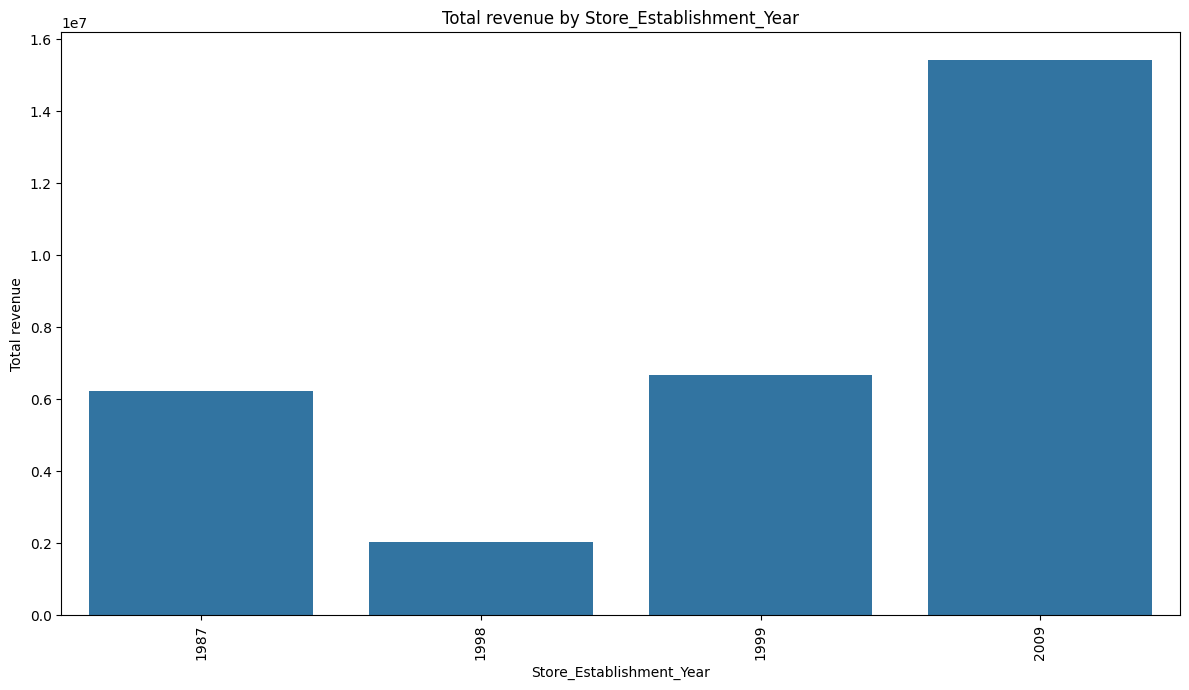

In [29]:
# plot betweeen Store established year vs product store sales total
bargraph_groupby_category('Store_Establishment_Year')

Observations
* The stores established during 2009 is contributing more revenue, followed by the stores established during 1999.
* The revenue generated by the stores established during the year 2009 is 15,427,583.43.
* Stores that were established during the year 1998 has contributed lowest revenue i.e., of 2,000,000 when compared.

In Product_Sugar_Content the most contributing record for the revenue is Low Sugar
The total revenue generated by Low Sugar is 16823405.80
 


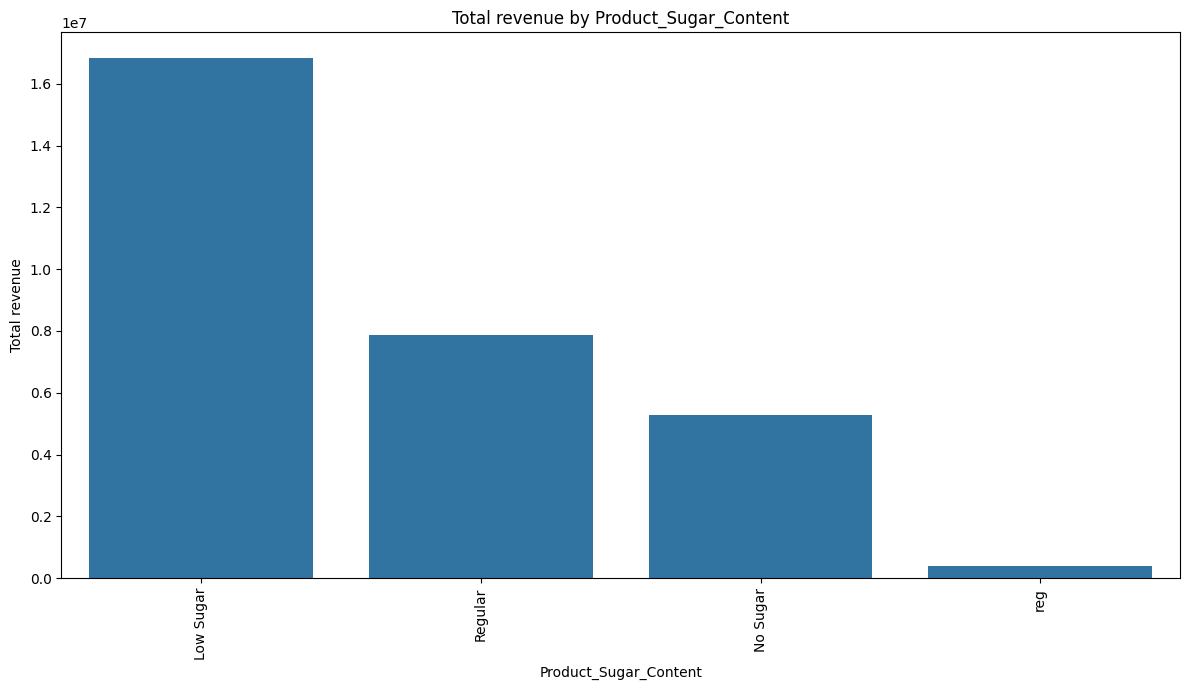

In [30]:
# plot betweeen Product_Sugar_Content vs Product_Store_Sales_Total
bargraph_groupby_category('Product_Sugar_Content')

Observations
* Low Sugar content is contributing more revenue, followed by Regular sugar content.
* The revenue generated by the low sugar content is approximately 16,823,405.80.
* No Sugar content is contributing lowest revenue i.e., of 7,000,000 when compared.

In Product_Type the most contributing record for the revenue is Fruits and Vegetables
The total revenue generated by Fruits and Vegetables is 4300833.27
 


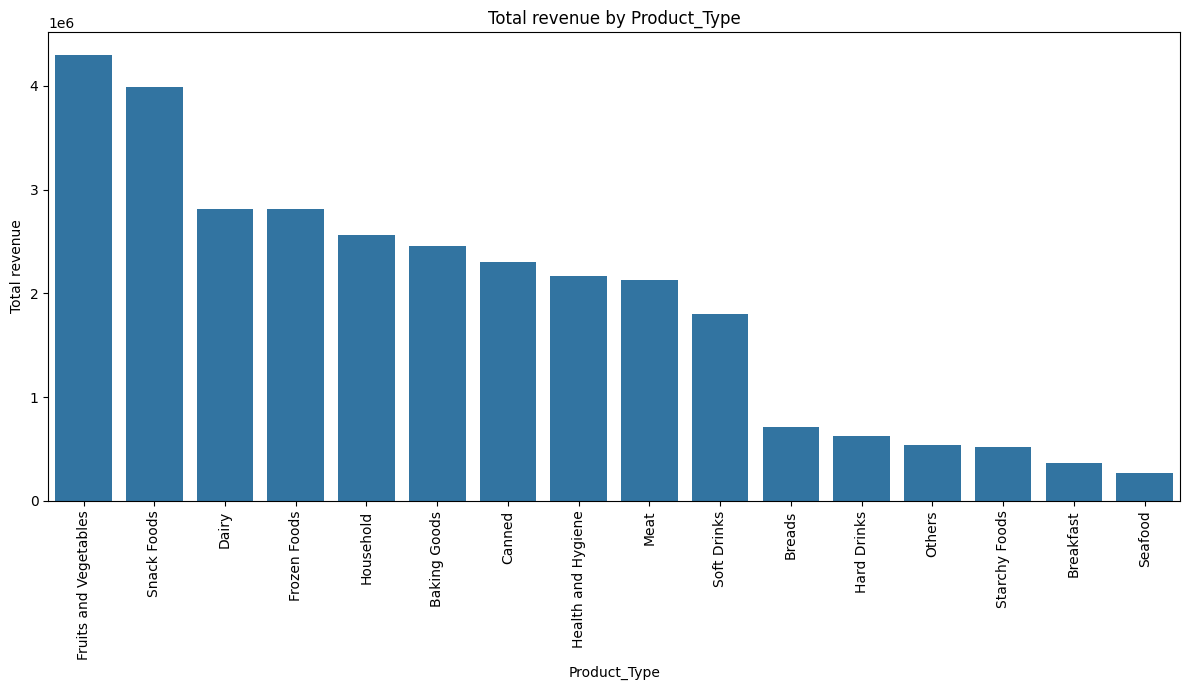

In [31]:
# plot betweeen Product_Type vs Product_Store_Sales_Total
bargraph_groupby_category('Product_Type')

Observations
* Fruits and Vegetables is contributing more revenue, followed by Snack Foods.
* The revenue generated by Fruits and Vegetables product type is approximately 4,300,833.27.
* Dairy and Frozen Foods product type were approximately contributing the same revenue i.e., of 2,800,000.
* Seafood is contributing lowest revenue approximately 200,000 when compared.

In Store_Id the most contributing record for the revenue is OUT004
The total revenue generated by OUT004 is 15427583.43
 


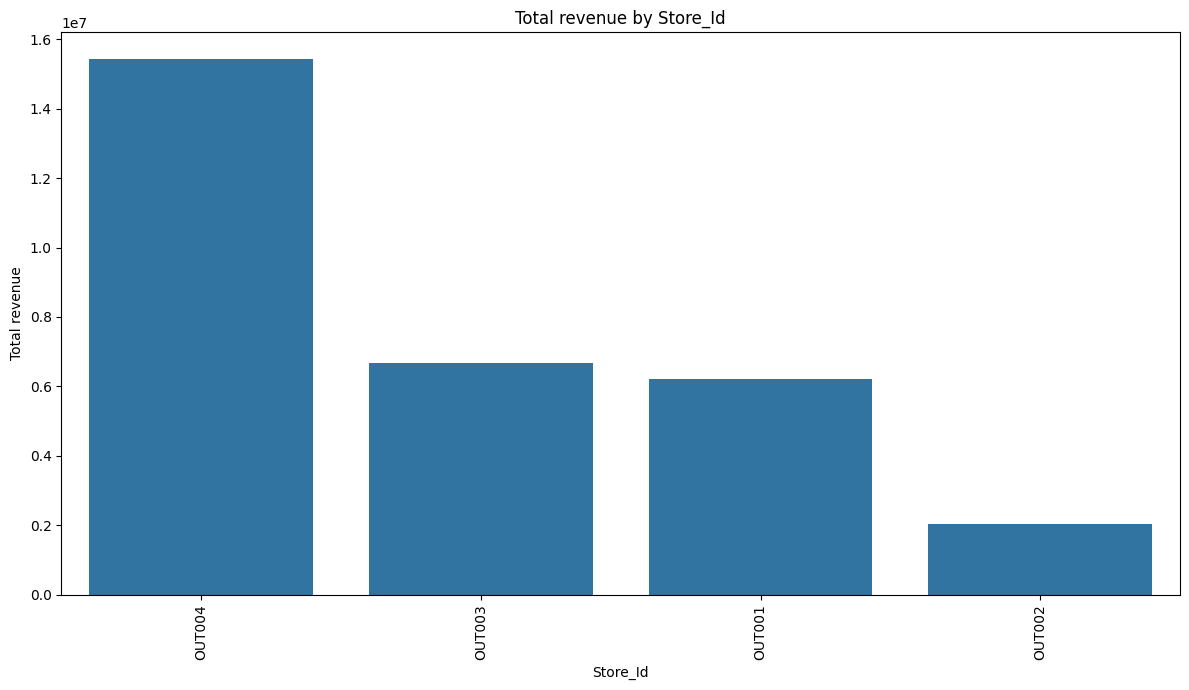

In [32]:
# plot betweeen Store_Id vs Product_Store_Sales_Total
bargraph_groupby_category('Store_Id')

Observations
* A store with store id 'OUT004' is contributing more revenue, followed by 'OUT003'.
* The revenue generated by 'OUT004' store is approximately 15,427,583.43.
* A store with store id 'OUT002' is contributing lowest revenue approximately 1,900,000 when compared.

In Store_Size the most contributing record for the revenue is Medium
The total revenue generated by Medium is 22101041.00
 


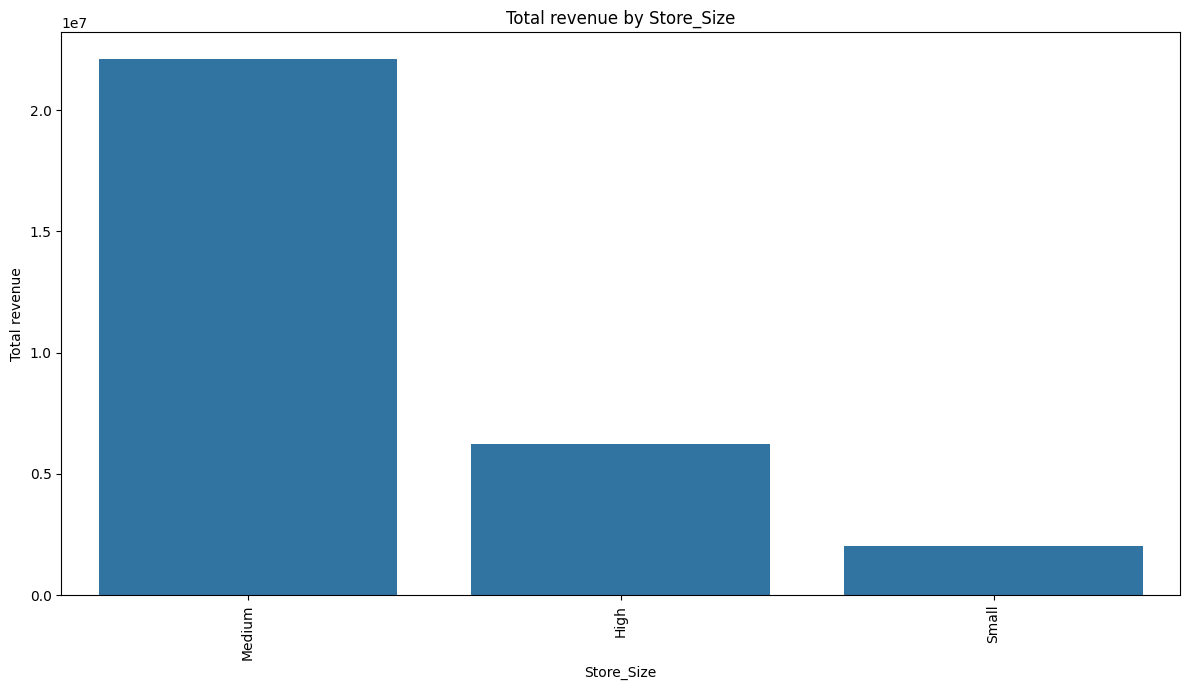

In [33]:
# plot betweeen Store_Size vs Product_Store_Sales_Total
bargraph_groupby_category('Store_Size')

Observations
* A store with 'Medium' size is contributing more revenue, followed by 'High' size store.
* The revenue generated by Medium store is approximately 22,101,041 and the High size store is generating a revenue of 6,000,000.
* A store with 'Small' size is contributing lowest revenue approximately 2,000,000.

In Store_Location_City_Type the most contributing record for the revenue is Tier 2
The total revenue generated by Tier 2 is 21650696.61
 


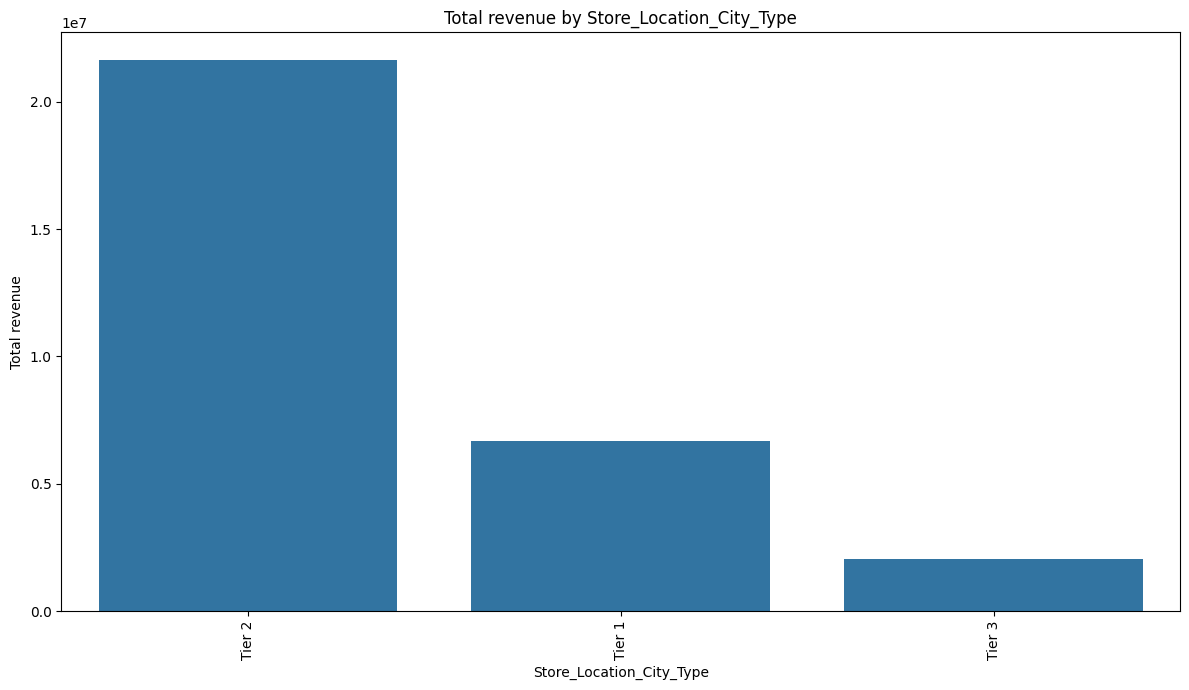

In [34]:
# plot betweeen Store_Location_City_Type vs Product_Store_Sales_Total
bargraph_groupby_category('Store_Location_City_Type')

Observations
* The stores located in 'Tier 2' were contributing more revenue, followed by stores located in 'Tier 1'.
* The revenue generated by the stores located in 'Tier 2' is approximately 21,650,696.61 and stores located in 'Tier 1' is generating a revenue approximately of 5,800,000.
* Stores located in 'Tier 3' were contributing lowest revenue approximately 2,000,000.

In Store_Type the most contributing record for the revenue is Supermarket Type2
The total revenue generated by Supermarket Type2 is 15427583.43
 


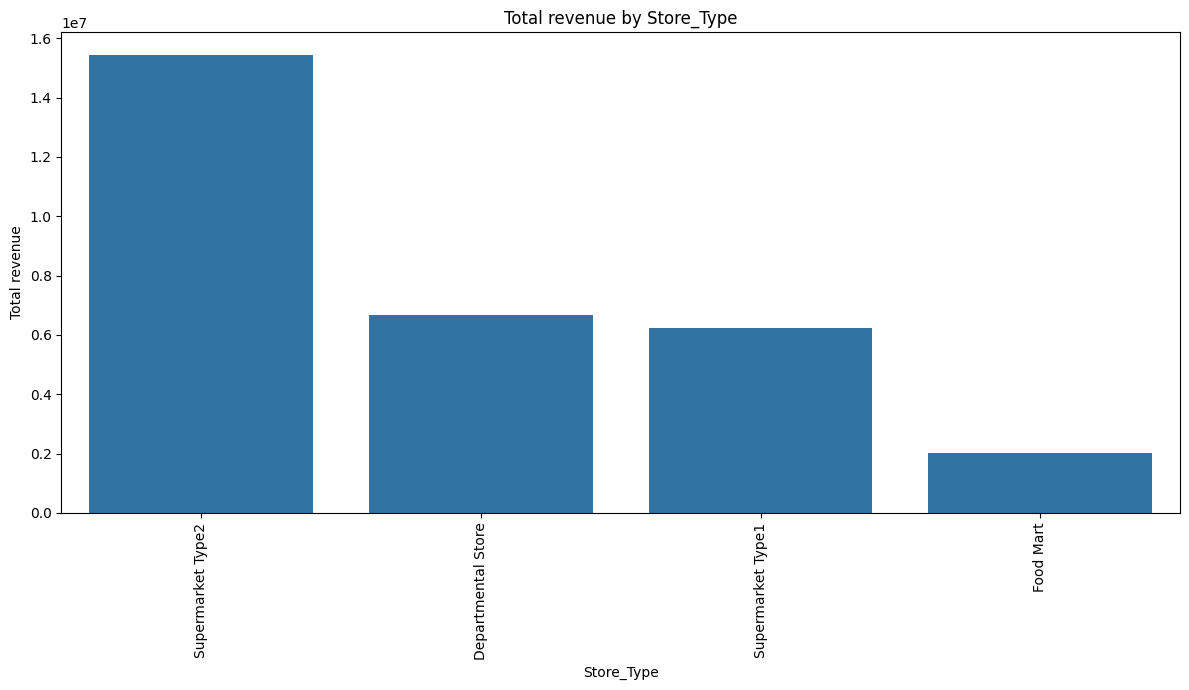

In [35]:
# plot betweeen Store_Type vs Product_Store_Sales_Total
bargraph_groupby_category('Store_Type')

Observations
* The Supermarket Type2 stores were contributing more revenue, followed by Departmental stores.
* The revenue generated by the Supermarket Type2 stores is approximately 15427583.43 and Departmental stores were generating revenue approximately of 6,200,000.
* Supermarket Type1 stores were generating revenue approximately of 6,000,000.
* Food Mart is contributing least revenue approximately of 2,000,000.

In [36]:
# Plot bargraph by grouping the two different categorical variables and calculate the revenue
def bar_group_two_category(cat_feature_1, cat_feature_2):
  """
  Grouping two categorical variables and estimating the revenue for each category
  cat_feature_1: First categorical feature
  cat_feature_2: Second categorical feature
  """
  # Grouping two categorical features and estimating total revenue
  grouped_data = dataset.groupby([cat_feature_1, cat_feature_2])[target].sum().reset_index()
  sorted_data = grouped_data.sort_values(by=target, ascending=False)

  plt.figure(figsize=(12, 7))     # Figure size
  sns.barplot(data=sorted_data, x=cat_feature_1, y=target, hue=cat_feature_2, palette='Paired')      # Bar plot
  plt.title(f'Revenue by {cat_feature_1} and {cat_feature_2}')    # Plot title
  plt.xlabel(cat_feature_1)     # X-label
  plt.ylabel('Total Revenue')   # Y-label
  plt.xticks(rotation=90)
  plt.show()

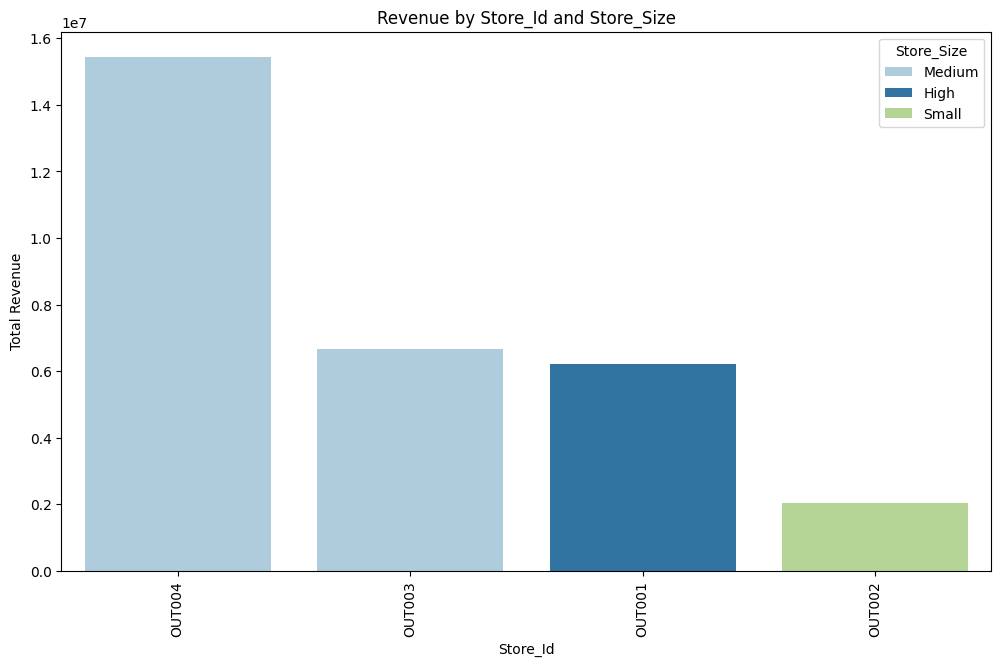

In [37]:
# Plotting revenue distribution by store_id and store_size
bar_group_two_category('Store_Id', 'Store_Size')

Observations
* The stores with store id's of 'OUT004' and 'OUT003', having medium size were contributing more revenue i.e., of approximately 15,200,000 and 6,200,000 respectively.
* The store with store id of 'OUT001' having high size store, approximately 6,000,000.
* While the store with an id of 'OUT002' has small size store and contributing low revenue, approximately 2,000,000.


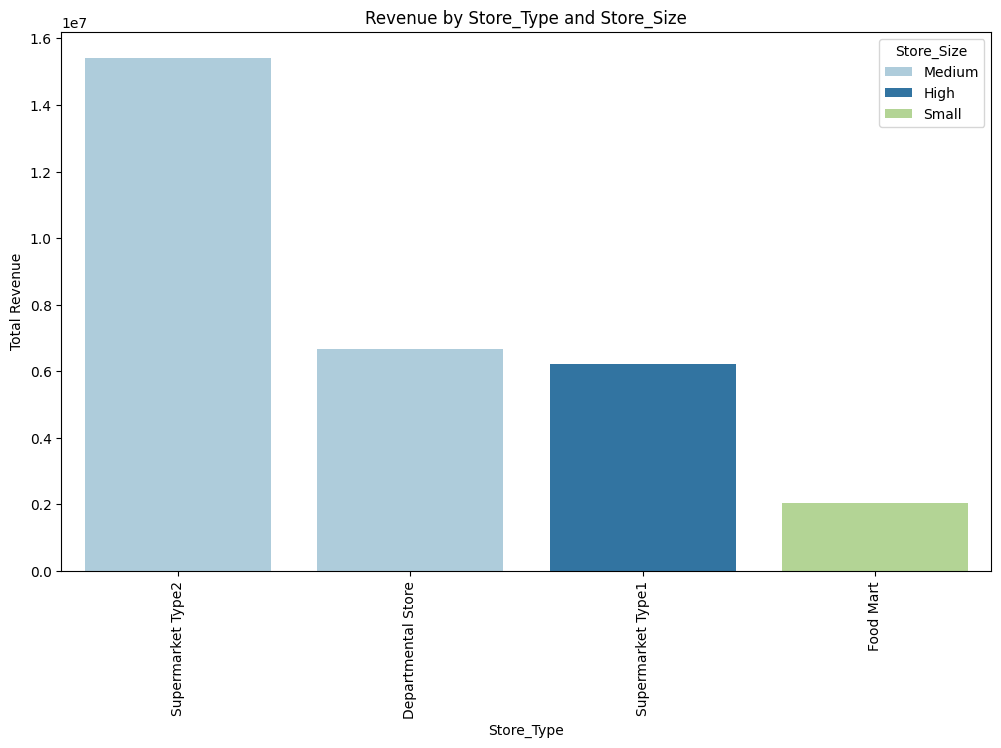

In [38]:
# Plotting revenue distribution by store_type and store_size
bar_group_two_category('Store_Type', 'Store_Size')

Observations
* The supermarket type2, with a medium size is contributing more revenue i.e., of approximately 15,200,000.
* Followed by the departmental store with medium size is generating more revenue i.e., of 6,200,000 approximately.
* The supermarket type1 with a high size is generating a revenue of 6,000,000 approximately.
* A food mart with small is generating lower revenue i.e., of 2,000,000 approximately when compared.


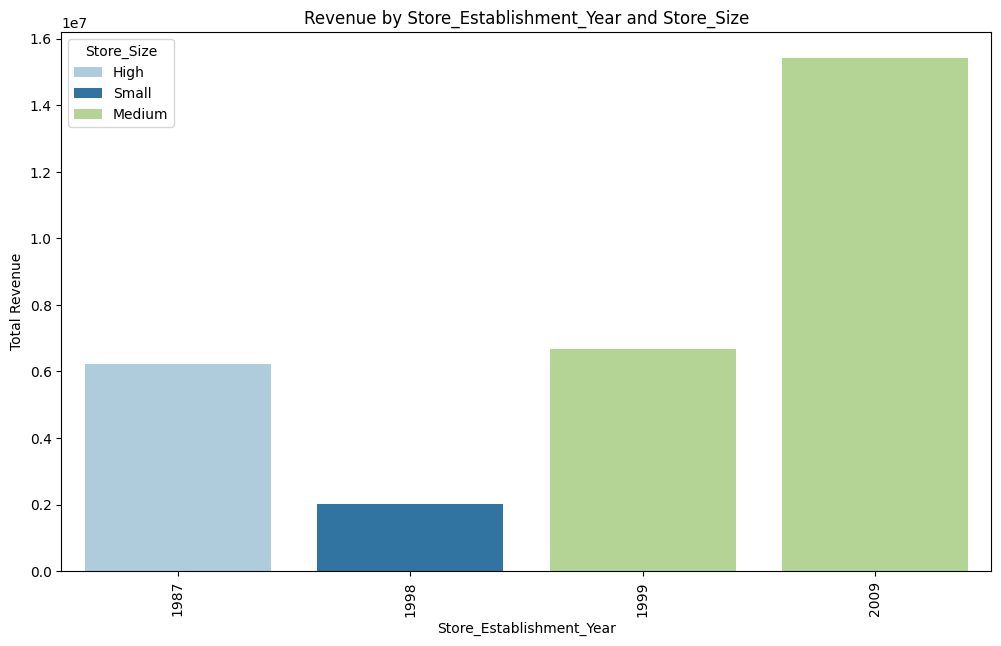

In [39]:
# Plotting revenue distribution by store established year and store_size
bar_group_two_category('Store_Establishment_Year', 'Store_Size')

Observations
* The stores which were established during the year 1987 were of high size, generating the revenue of 6,100,000.
* The medium size stores which were established during the year 1999 and 2009 were generating a revenue of 6,200,000 and 15,200,000 respectively.
* The small size stores which were established during 1998 were generating lower revenue i.e., of 2,000,000 approximately when compared.


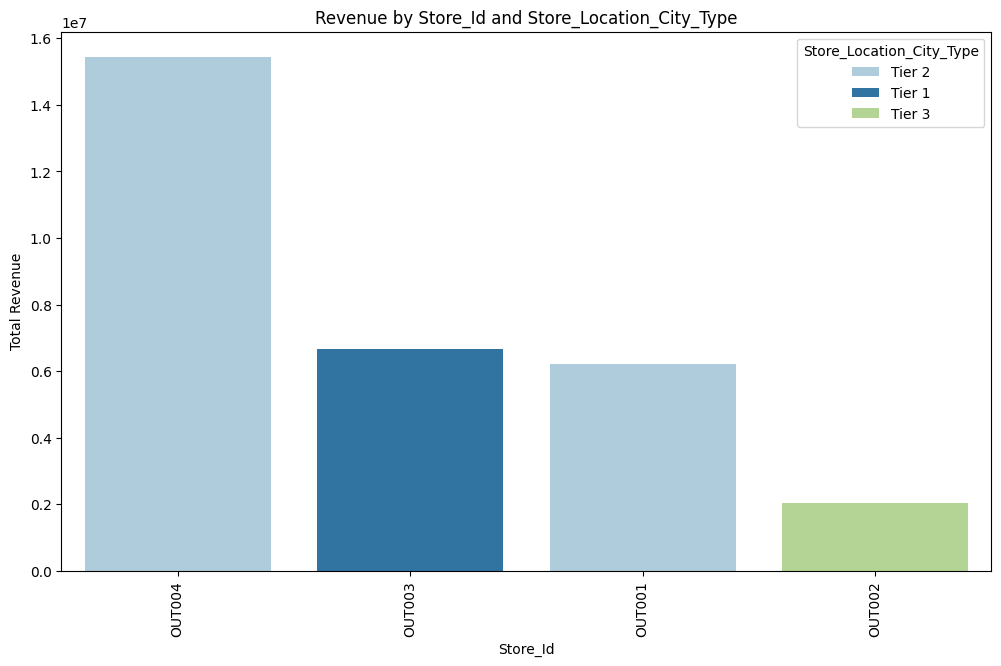

In [40]:
# Plotting revenue distribution by store_id and store_location_type
bar_group_two_category('Store_Id', 'Store_Location_City_Type')

Observations
* The store with the store id 'OUT004', located in 'Tier 2' city was generating more income approximately 15,200,000.
* Followed by the store with id of 'OUT003', located in 'Tier 1' was generating income approximately of 6,200,000.
* The store with the store id 'OUT002', located in 'Tier 3' city was generating low income approximately 2,000,000.


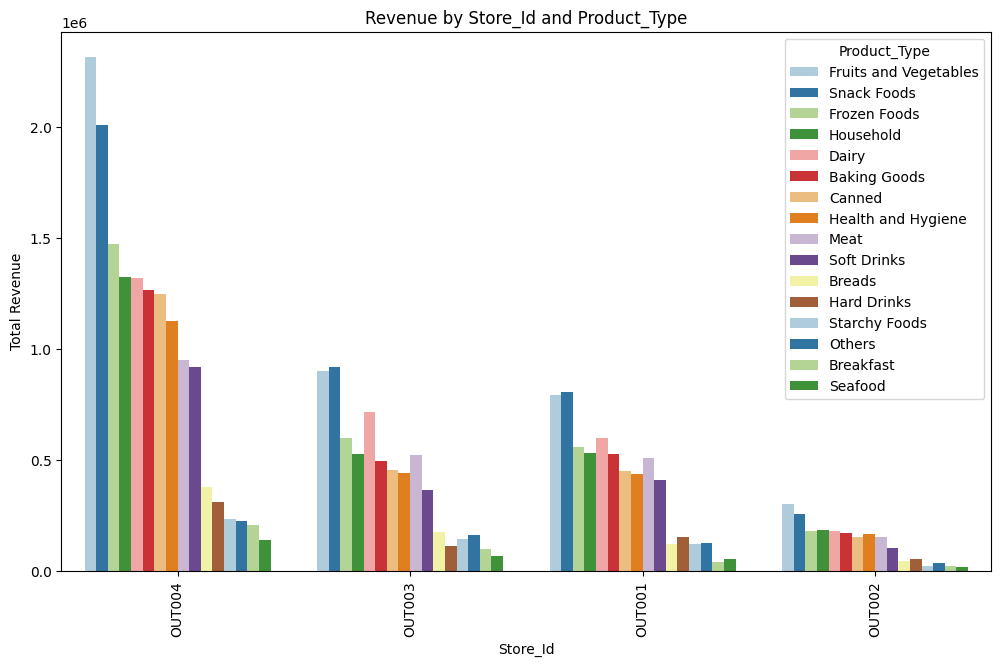

In [41]:
# Plotting revenue distribution by store_id and product_type
bar_group_two_category('Store_Id', 'Product_Type')

Observations
* The store with an id of 'OUT004', generating more revenue by selling Fruits and vegetables i.e., of 2,300,000, followed by snack food i.e., of 2,000,000 and the similar trend is observed in 'OUT002' store i.e., Fruits and vegetables and snack food of 350,000 and 300,000 respectively.
* The store with an id of 'OUT003' and 'OUT001', generating more revenue by selling snack food, followed by fruits and vegetables and the similar trend is observed in 'OUT001' stores.
* Seafood is the lowest selling food category in the all the stores i.e., in store 'OUT001', 'OUT002', 'OUT003' and 'OUT004' the revenue generated is of 90,000, 50,000, 100,000 and 200,000 respectively.

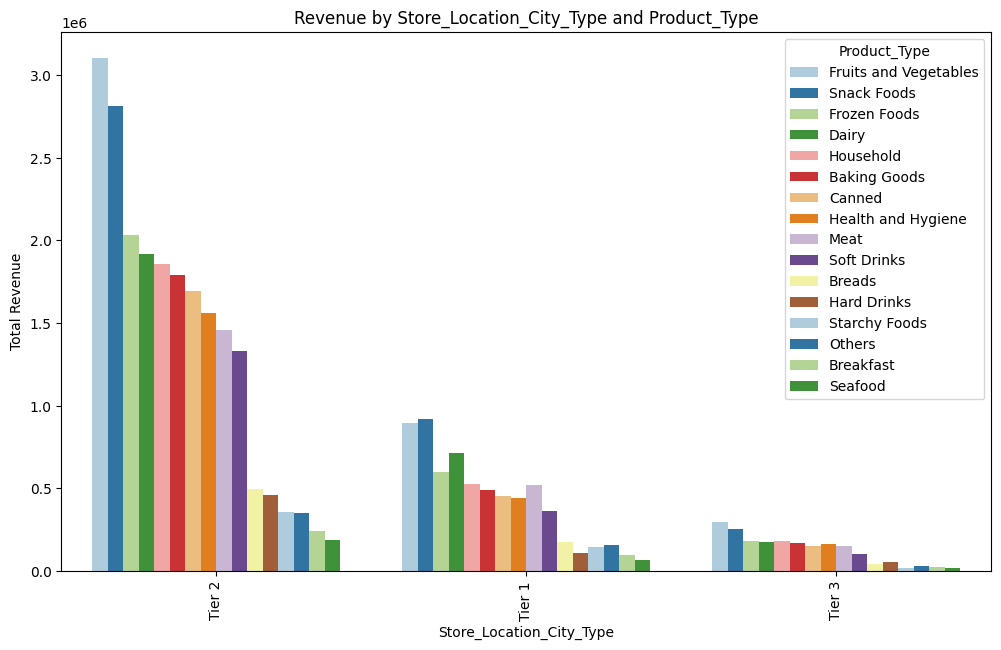

In [42]:
# Plotting revenue distribution by store_location and product_type
bar_group_two_category('Store_Location_City_Type', 'Product_Type')

Observations
* The store located in 'Tier-2' city is generating revenue of 3,200,000 by selling 'Fruits and Vegetables', followed by 'Snack Foods' generating revenue of 2,800,000.
* The store located in 'Tier-1' city is generating revenue of 900,000 by selling 'Snack Foods', followed by 'Fruits and Vegetables' generating revenue of 850,000.
* The store located in 'Tier-3' city is generating revenue of 300,000 by selling 'Fruits and Vegetables', followed by 'Snack Foods' generating revenue of 280,000.
* Seafood is the lowest selling food category in the all the city tiers i.e., in 'Tier 1', 'Tier 2' and 'Tier 3' the revenue generated is of 100,000, 50,000 and 200,000 respectively.

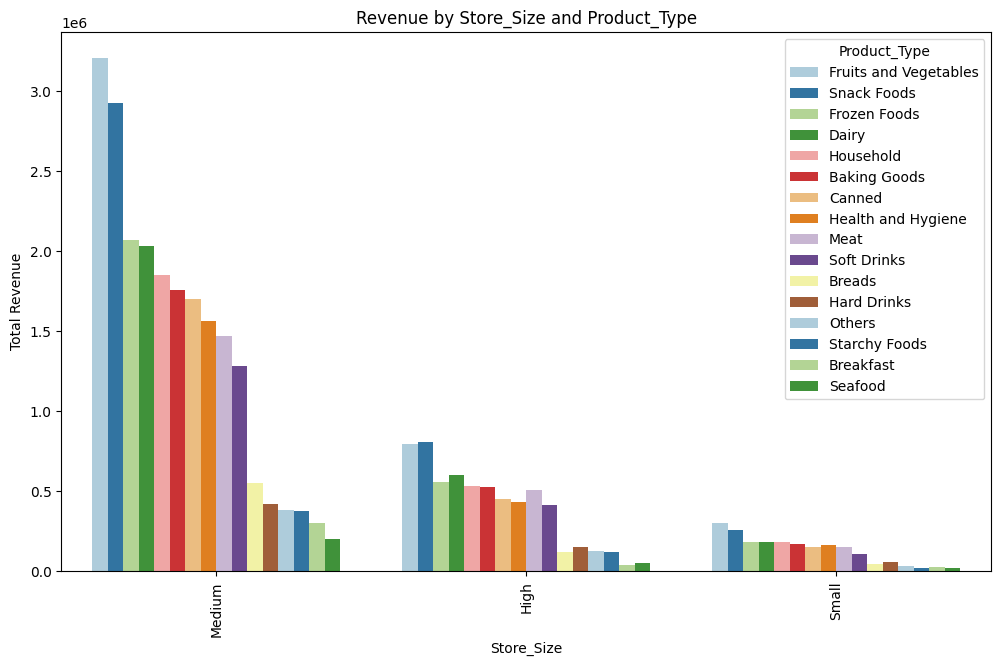

In [43]:
# Plotting revenue distribution by store_size and product_type
bar_group_two_category('Store_Size', 'Product_Type')

Observations
* The store with medium size is generating revenue of 3,300,000 by selling 'Fruits and Vegetables', followed by 'Snack Foods' generating revenue of 2,900,000.
* The store with high size is generating revenue of 700,000 by selling 'Snack Foods', followed by 'Fruits and Vegetables' generating revenue of 680,000.
* The store with small size is generating revenue of 300,000 by selling 'Fruits and Vegetables', followed by 'Snack Foods' generating revenue of 280,000.
* Seafood is the lowest selling food category in the all the store sizes i.e., in 'Small', 'Medium' and 'High' the revenue generated is of 50,000, 100,000 and 200,000 respectively.

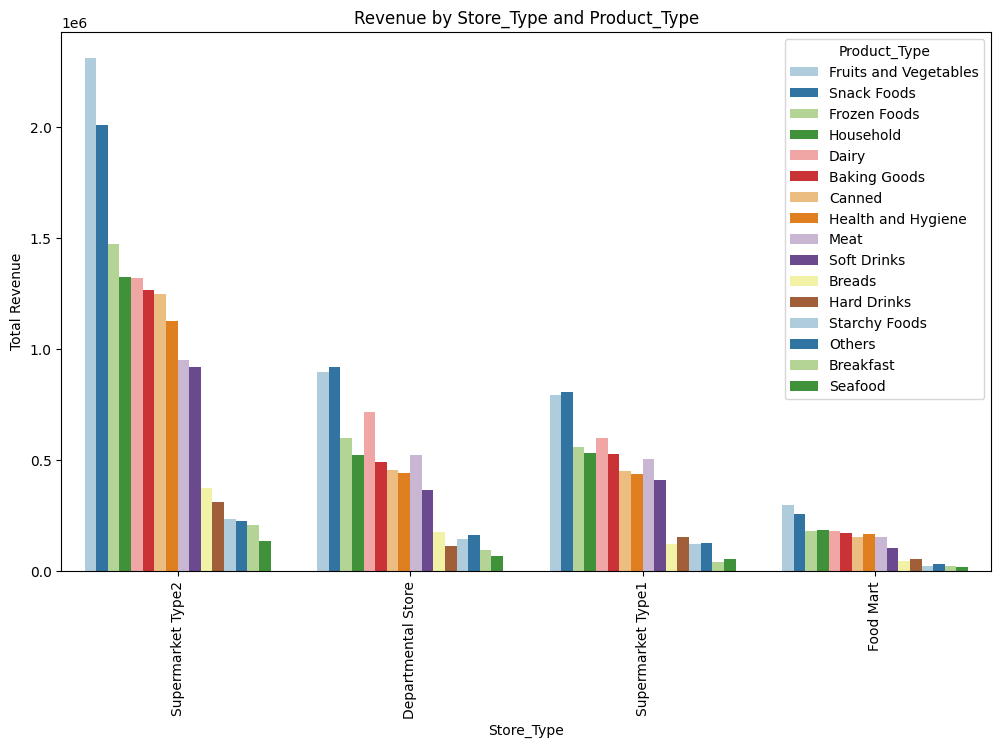

In [44]:
# Plotting revenue distribution by store_type and product_type
bar_group_two_category('Store_Type', 'Product_Type')

Observations
* The supermarket type-2 store is generating more revenue of 2,800,000 by selling 'Fruits and Vegetables', followed by 'Snack Foods' generating revenue of 2,000,000.
* The departmental store is generating more revenue of 900,000 by selling 'Snack Foods', followed by 'Fruits and Vegetables' generating revenue of 850,000.
* The supermarket type-1 store is generating more revenue of 800,000 by selling 'Snack Foods', followed by 'Fruits and Vegetables' generating revenue of 780,000.
* The foodmart store is generating more revenue of 300,000 by selling 'Fruits and Vegetables', followed by 'Snack Foods' generating revenue of 270,000.
* Seafood is the lowest selling food category in the all the store types i.e., in 'supermarket type-2', 'departmental store', 'supermarket type-1' and 'food mart' the revenue generated is of 100,000, 50,000, 40,000 and 20,000 respectively.

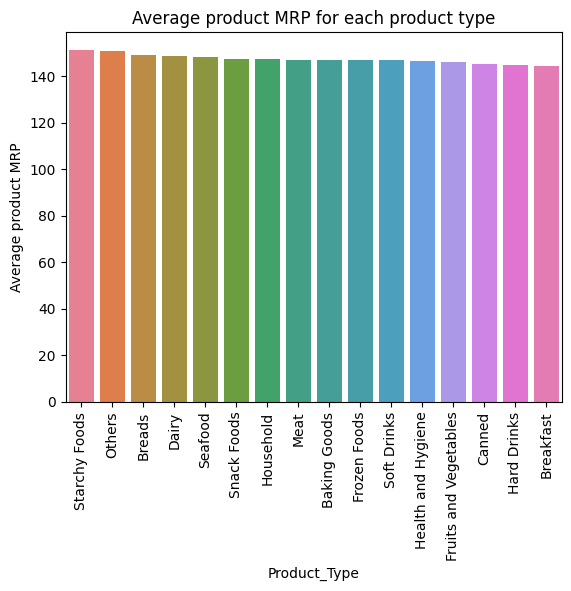

In [45]:
# Plotting product_MRP for each product_type
# Grouping product_type with respect to product_mrp and estimate average
group_type_mrp = dataset.groupby('Product_Type')['Product_MRP'].mean().reset_index()

# Sorting data by average product mrp
sorted_dt = group_type_mrp.sort_values(by='Product_MRP', ascending=False)

# Plotting bar graph
sns.barplot(data=sorted_dt, x='Product_Type', y='Product_MRP', hue='Product_Type')
plt.title('Average product MRP for each product type')    # Plot title
plt.xticks(rotation=90)
plt.xlabel('Product_Type')            # X-label
plt.ylabel('Average product MRP')     # Y-label
plt.show()

Observations
* The Starchy Foods product type, having an average MRP of 152, which is highest of all the product types.
* The 'Fruits and Vegetables' is the highest contributor for revenue generation, it's average MRP is around 148.
* The Breakfast product type, having an average MRP of 146, which is lowest of all the product types.

###Insights

* There are more number of products weighing in-between 7.5 to 17.5.
* There are more number of products allocated with an area approximately in-between 0.001 to 0.125.
* There are more number of products having an mrp in-between 100 to 200.
* The latest store was established during the year 2009, where there are 4700 stores.
* There are more number of total sales of the product in a prticular store is in-between 2,000 to 5,000.
* Approximately 26.92% of products has regular sugar content.
* Fruits and Vegetables constitute the largest segment of the inventory at approximately 14.25%, whereas Seafood represents the smallest share at roughly 0.87%.
* The store distribution is dominated by OUT004, which accounts for 53.36% of the total, while OUT002 has the smallest footprint at 13.15%.
* The store network is primarily composed of Medium size units at 68.75%, with Small size units making up the lowest portion of the distribution at 13.15%.
* There are more number of stores located in tier-2 city i.e., of 71.46%, while least number of stores located in tier-3 i.e., of 13.15%.
* There are more number of supermaket type2 stores i.e., of 53.36% and least number of food mart type stores i.e., of 13.15%.
* The Product_MRP and Product_Store_Sales_Total attributes are highly correlated i.e., of 0.79; while Product_Store_Sales_Total and Product_Allocated_Area attributes were least correlated i.e., of -0.00093.
* The stores established during 2009 is contributing more revenue.
* Products with low sugar content is contributing more revenue.
* Product type of fruits and vegetables is contributing more revenue.
* A store with store id of 'OUT004' is contributing more revenue.
* A store with 'Medium' size is contributing more revenue.
* Stores which were located in 'Tier 2' were contributing more revenue.
* The Supermarket Type2 stores were contributing more revenue.
* The stores with store id's of 'OUT004' and 'OUT003', having medium size were contributing more revenue.
* The supermarket type2 stores, with a medium size is generating more revenue.
* The medium size stores which were established during the year 1999 and 2009 were generating a revenue.
* The store with the store id 'OUT004', located in 'Tier 2' city was generating more income.
* The store with an id of 'OUT004' is generating more revenue by selling Fruits and vegetables.
* The store located in 'Tier-2' city is generating revenue by selling 'Fruits and Vegetables'.
* The store with medium size is generating more revenue by selling 'Fruits and Vegetables'.
* The supermarket type-2 store is generating more revenue by selling 'Fruits and Vegetables'.


# **Data Preprocessing**

##Outlier Detection

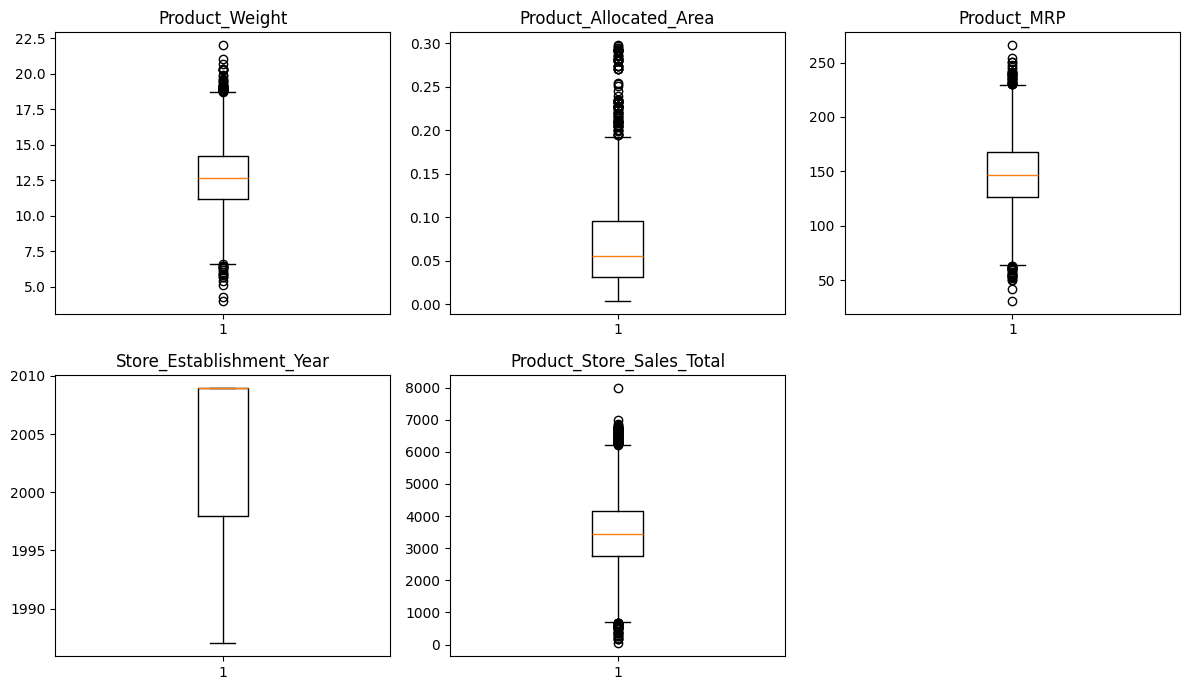

In [46]:
# Checking for outliers in numerical variables
plt.figure(figsize=(12,7))  # Figure size

# Iterate over each numerical column to check for outliers
for i, col in enumerate(dataset.select_dtypes(include='number').columns.tolist()):
  plt.subplot(2, 3, i+1)
  plt.boxplot(dataset[col], whis=1.5)     # Boxplot
  plt.tight_layout()
  plt.title(col)
plt.show()

Observations
* There are too many outliers in the attributes of 'Product_Weight', 'Product_Allocated_Area', 'Product_MRP' and 'Product_Store_Sales_Total'; and treating these outliers is not required, since they are reflecting real-world conditions which will be useful for forecasting the sales.

## Feature Engineering

* In 'Product_Sugar_Content' attribute there are few records of type 'reg', which is a short form of 'Regular' which requires to be corrected.
* There are almost 16 unique records in Product_Type attribute, when one-hot encoding is performed on this attribute then the number of attributes will increase, therefore it is necessary to arrange the unique records into two categories i.e., of 'Food and Beverage' which consists of [Frozen Foods', 'Dairy', 'Canned', 'Baking Goods', 'Snack Foods', 'Meat', 'Hard Drinks', 'Fruits and Vegetables', 'Breads', 'Soft Drinks', 'Breakfast', 'Starchy Foods', 'Seafood'] and 'General Household' which consists of ['Health and Hygiene', 'Household', 'Others']
* Converting the 'Store_Establishment_Year' atrribute to 'Store_Age', by subtracting current year from store_establishment_year and here the current year is considered as 2010, since in the the latest year the store was established is on 2009.
* Also, there is too much of variability in the Product_Store_Sales_Total attribute, which is ranging from 33 to 8000, it would be better to convert to logarithmic scale so that the data gets normalized.

In [47]:
# Replacing few records in product sugar content
dataset['Product_Sugar_Content'] = dataset['Product_Sugar_Content'].replace('reg', 'Regular')

# Checking for corrected records
dataset['Product_Sugar_Content'].unique()

array(['Low Sugar', 'Regular', 'No Sugar'], dtype=object)

* Few records in 'Product_Sugar_Content' attribute were successfully replaced to 'Regular' from 'reg'.

In [48]:
# Grouping product type into 2 categories
general_household = ['Health and Hygiene', 'Household', 'Others']

# Reducing 16 records in Product_Type to 2 records
dataset['Product_Type_Category'] = dataset['Product_Type'].apply(lambda x: 'General Household' if x in general_household else 'Food and Beverages')

# Checking for newly created attribute
print(dataset['Product_Type_Category'].unique())
print(' ')

# Checking first 5 records
dataset.head()

['Food and Beverages' 'General Household']
 


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,Food and Beverages
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,Food and Beverages
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,Food and Beverages
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,Food and Beverages
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,General Household


* A new attribute called 'Product_Type_Category' is added with 2 records which is the replacement of 'Product_Type' with 16 records.

In [49]:
# Getting the latest year the store established
dataset['Store_Establishment_Year'].max()

2009

In [50]:
# Converting the store_establishment_year to age of the store
dataset['Store_Age'] = 2010 - dataset['Store_Establishment_Year']

# Checking for first 5 records in the dataset
dataset.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Type_Category,Store_Age
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,Food and Beverages,1
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,Food and Beverages,11
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,Food and Beverages,23
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,Food and Beverages,23
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,General Household,12


* Store_Age attribute i.e., the age of the store is added successfully, which acts as a replacement of 'Store_Establishment_Year'.

In [51]:
# converting product_store_sales_total to logarithmic scale for normalization
dataset['Product_Store_Sales_Total_log'] = np.log(dataset['Product_Store_Sales_Total'])

# Checking for first 5 records in the dataset
dataset.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Type_Category,Store_Age,Product_Store_Sales_Total_log
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,Food and Beverages,1,7.952404
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,Food and Beverages,11,8.482606
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,Food and Beverages,23,8.326071
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,Food and Beverages,23,8.326560
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,General Household,12,7.731650


In [52]:
# Dropping Store_Establishment_Year, Product_Type and product_store_sales_total columns
df = dataset.drop(['Product_Type', 'Store_Establishment_Year', 'Product_Store_Sales_Total'], axis=1)

# Checking first 5 records in the dataset to verify the dropping of 3 attributes
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Id,Store_Size,Store_Location_City_Type,Store_Type,Product_Type_Category,Store_Age,Product_Store_Sales_Total_log
0,FD6114,12.66,Low Sugar,0.027,117.08,OUT004,Medium,Tier 2,Supermarket Type2,Food and Beverages,1,7.952404
1,FD7839,16.54,Low Sugar,0.144,171.43,OUT003,Medium,Tier 1,Departmental Store,Food and Beverages,11,8.482606
2,FD5075,14.28,Regular,0.031,162.08,OUT001,High,Tier 2,Supermarket Type1,Food and Beverages,23,8.326071
3,FD8233,12.10,Low Sugar,0.112,186.31,OUT001,High,Tier 2,Supermarket Type1,Food and Beverages,23,8.326560
4,NC1180,9.57,No Sugar,0.010,123.67,OUT002,Small,Tier 3,Food Mart,General Household,12,7.731650


In [53]:
# Checking the shape of the data
df.shape

(8763, 12)

* After feature engineering, the dataset has 12 attributes with 8763 records.
* The product_id will be dropped in the subsequent steps i.e., after splitting the dataset into train, validation and test sets. Since product_id will be used to tag with it's respective predicted sale when the model is serialized.

##Data preparation for Modeling

In [54]:
# Selecting independent variables
X = df.drop('Product_Store_Sales_Total_log', axis=1)

# Selecting dependent variable
y = df['Product_Store_Sales_Total_log']

In [55]:
# Splitting data into 3 parts i.e., train, validation and test set

# Splitting data into 2 parts i.e., train and temp
X_train_df, X_temp_df, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=RS)

# Splitting temp data into 2 parts i.e., validation and test set
X_val_df, X_test_df, y_val, y_test = train_test_split(X_temp_df, y_temp, test_size=0.5, random_state=RS)

* Dropping product_id from the train, validation and test split, since it is unique and doesn't provide much significance for further analysis.

In [56]:
# Drop product_id from the train, validation and test dataset
X_train = X_train_df.drop('Product_Id', axis=1)
X_val = X_val_df.drop('Product_Id', axis=1)
X_test = X_test_df.drop('Product_Id', axis=1)

In [57]:
print(f'For independent variable the total number of records in the train set is of {X_train.shape[0]} with {X_train.shape[1]} attributes')
print(f'For independent variable the total number of records in the validation set is of {X_val.shape[0]} with {X_val.shape[1]} attributes')
print(f'For independent variable the total number of records in the test set is of {X_test.shape[0]} with {X_test.shape[1]} attributes')
print(' ')
print(f'For dependent variable the total number of records in the train set is of {y_train.shape[0]}')
print(f'For dependent variable the total number of records in the validation set is of {y_val.shape[0]}')
print(f'For dependent variable the total number of records in the test set is of {y_test.shape[0]}')

For independent variable the total number of records in the train set is of 7010 with 10 attributes
For independent variable the total number of records in the validation set is of 876 with 10 attributes
For independent variable the total number of records in the test set is of 877 with 10 attributes
 
For dependent variable the total number of records in the train set is of 7010
For dependent variable the total number of records in the validation set is of 876
For dependent variable the total number of records in the test set is of 877


##Data Preprocessing

* Every record in numerical attribute is variying i.e, 'Product_Weight' is ranging from 4 to 22, 'Product_Allocated_Area' varies from 0.004 to 0.298, 'Product_MRP' varying from 31 to 266 and 'Store_Age' ranges from 1 to 23. Therefore, it is better to scale every record for its respective attribute so that every feature contributes equally to the model's performance, preventing attributes with larger range dominating the model's performance.
* Encoding the categorical variable, so that it gets converted to numerical feature, which will be very helpful for training the model.

In [58]:
# Select categorical features
categorical_features = X_train.select_dtypes(include='object').columns.tolist()
print(f'The list of categorical features were {categorical_features}')

# Select numerical features
numerical_features = X.select_dtypes(include='number').columns.tolist()
print(f'The list of numerical features were {numerical_features}')

The list of categorical features were ['Product_Sugar_Content', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Type_Category']
The list of numerical features were ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age']


In [59]:
# Creating a preprocessing pipeline for categorical features
preprocessor = make_column_transformer(
    (Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore'))]),     # onehot-encoding of categorical feature and ignore unknown categorical record
              categorical_features),                                      # List of Categorical features
    (Pipeline([('scaler', StandardScaler())]),                            # Scaling the numerical features
             numerical_features)                                          # List of Numerical features
)

* The pipeline is used to convert the categorical columns into one hot encoded vectors and also scaling the numerical features.

# **Model Building**

## Model Evaluation Criteria

* The main objective is to accurately forecast the sales revenue of its outlets, the difference between the actual and the predicted sale should be as low as possible. A lower error directly translates to better inventory management for SuperKart.
* R-squared and Adjusted R-squared measure how much of the sales variance is explained by the predictors. Adjusted R-squared penalizes by adding "noise" variables that don't actually help the forecast.
* Therefore, RMSE is used as the evaluation criterion to penalize large errors. Because it squares the differences, it is highly sensitive to large misses. This is vital for SuperKart because a massive under-prediction at a major outlet is more damaging than a few small errors at tiny marts.
* RMSE is used for hyperparameter tuning for optimizing the model.

## Define functions for Model Evaluation

In [60]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

* Choosing Random Forest and XGBoost regressors as two ML models for forecasting the sales.

##Random Forest Regressor - Model Training Pipeline

In [61]:
# Define random forest base model
randf_model = RandomForestRegressor(random_state=RS)

# Creating the model pipeline with preprocessing and random forest model
rf_pipeline = make_pipeline(preprocessor, randf_model)

# Train the model with training data
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Id', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [62]:
# Check the model performance on train data
rf_model_train_perf = model_performance_regression(rf_pipeline, X_train, y_train)
rf_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.03946,0.01335,0.988327,0.988311,0.001728


In [63]:
# Check the model performance on validation data
rf_model_val_perf = model_performance_regression(rf_pipeline, X_val, y_val)
rf_model_val_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.106165,0.037283,0.914261,0.91327,0.00477


Observations
* The metrics of RMSE, MAE, R-Square, Adjusted R-Square and MAPE for train data were 0.039, 0.013, 0.988, 0.988 and 0.0017 respectively.
* The metrics of RMSE, MAE, R-Square, Adjusted R-Square and MAPE for validation data were 0.106, 0.037, 0.914, 0.913 and 0.0047 respectively.
* The Random Forest model is over-fitting, since it has lower RMSE value on train data i.e., of 0.039 when compared to the validation data i.e., 0.106. This indicates the model is capturing the noise and underlying patterns in the train data.
* Since it is a base model, the model performance is not giving a generalized performance, it would be better to tune the model.

## XGBoost Regressor - Model Training Pipeline

In [64]:
# Define xgboost base model
xgb_model = XGBRegressor(random_state=RS)

# Creating the model pipeline with preprocessing and xgboost model
xgb_pipeline = make_pipeline(preprocessor, xgb_model)

# Train the model with training data
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Id', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Prod...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

In [65]:
# Check the model performance on train data
xgb_model_train_perf = model_performance_regression(xgb_pipeline, X_train, y_train)
xgb_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.043331,0.02017,0.985926,0.985905,0.002528


In [66]:
# Check the model performance on validation data
xgb_model_val_perf = model_performance_regression(xgb_pipeline, X_val, y_val)
xgb_model_val_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.109893,0.046393,0.908133,0.907071,0.00594


Observations
* The metrics of RMSE, MAE, R-Square, Adjusted R-Square and MAPE for train data were 0.043, 0.0201, 0.985, 0.985 and 0.0025 respectively.
* The metrics of RMSE, MAE, R-Square, Adjusted R-Square and MAPE for validation data were 0.109, 0.046, 0.908, 0.907 and 0.0059 respectively.
* The Xgboost model is over-fitting, since it has lower RMSE value on train data i.e., of 0.043 when compared to the validation data i.e., 0.109. This indicates the model is capturing the noise and underlying patterns in the train data.
* Since it is a base model, the model performance is not giving a generalized performance, it would be better to tune the model.


# **Model Performance Improvement - Hyperparameter Tuning**

## Random Forest Regressor - Hyperparameter Tuning

In [67]:
# Define random forest base model
randf_tuned = RandomForestRegressor(random_state=RS)

# Create pipeline with preprocessing and random forest model
randf_tuned_pipeline = make_pipeline(preprocessor, randf_tuned)

# Parameters for tuning the model
parameters = {
    'randomforestregressor__max_depth': [3, 5, 6, 7],
    'randomforestregressor__n_estimators': [150, 200, 250],
    'randomforestregressor__max_features': np.arange(0.2, 0.7, 0.1),
    'randomforestregressor__max_samples': np.arange(0.2, 0.7, 0.1)
}

# Scorer for comparing the models
scorer = metrics.make_scorer(metrics.root_mean_squared_error, greater_is_better=False)

# Grid serach to select the best parameters and best model
grid_obj = GridSearchCV(randf_tuned_pipeline, parameters, scoring=scorer, cv=5, verbose=2, n_jobs=-1)
grid_obj.fit(X_train, y_train)

# Get the best model with the combination of best parameters
randf_tuned = grid_obj.best_estimator_

# Fit the train data to the best tuned model
randf_tuned.fit(X_train, y_train)

Fitting 5 folds for each of 300 candidates, totalling 1500 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Id', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=7,
                                       max_features=np.float64(0.6000000000000001),
                                       max_samples=np.float64(0.6000000000000001),
                                       n_estimators=250, random_state=42))])

In [68]:
# Check the model performance on train data
randf_tuned_train_perf = model_performance_regression(randf_tuned, X_train, y_train)
randf_tuned_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.101371,0.050353,0.922969,0.922859,0.006473


In [69]:
# Check the model performance on validation data
randf_tuned_val_perf = model_performance_regression(randf_tuned, X_val, y_val)
randf_tuned_val_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.116604,0.057171,0.89657,0.895374,0.007305


Observations
* The metrics of RMSE, MAE, R-Square, Adjusted R-Square and MAPE for train data were 0.101, 0.050, 0.922, 0.922 and 0.0064 respectively.
* The metrics of RMSE, MAE, R-Square, Adjusted R-Square and MAPE for validation data were 0.116, 0.057, 0.896, 0.895 and 0.0073 respectively.
* The Random Forest tuned model is giving a generalized performance, since the RMSE value on train and validation data is almost equal i.e., on train data the value is of 0.101 and on validation data the value is of 0.116. Also the relative gap between the train and validation data is of 15.02% (((0.116-0.101)/0.101)*100), which is better when compared with the base models.
* Therefore, a tuned model is giving a generalized performance on unseen data.

## XGBoost Regressor - Hyperparameter Tuning

In [70]:
# Define the xgboost base model
xgb_tuned = XGBRegressor(random_state=RS)

# Create a pipeline with preprocessing and xgboost model
xgb_pipeline = make_pipeline(preprocessor, xgb_tuned)

# Parameters for tuning the mode
parameters = {
    'xgbregressor__n_estimators': [100, 150, 200],
    'xgbregressor__max_depth': [3, 5, 7],
    'xgbregressor__subsample': [0.5, 0.7, 0.9],
    'xgbregressor__learning_rate': [0.01, 0.1, 0.2, 0.005],
    'xgbregressor__colsample_bytree': [0.5, 0.7, 0.9, 1],
}

# Scorer used for comparing the models
scorer = metrics.make_scorer(metrics.root_mean_squared_error, greater_is_better=False)

# Grid search to select the best parameters and best model
grid_obj = GridSearchCV(xgb_pipeline, parameters, scoring=scorer, cv=5, verbose=2, n_jobs=-1)
grid_obj.fit(X_train, y_train)

# Get the best model with the combination of best parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the train data to the best tuned model
xgb_tuned.fit(X_train, y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Id', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Prod...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=7, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

In [71]:
# Check the model performance on train data
xgb_tuned_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
xgb_tuned_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.061452,0.024982,0.971692,0.971651,0.003152


In [72]:
# Check the model performance on validation data
xgb_tuned_val_perf = model_performance_regression(xgb_tuned, X_val, y_val)
xgb_tuned_val_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.10679,0.041555,0.913248,0.912245,0.005313


Observations
* The metrics of RMSE, MAE, R-Square, Adjusted R-Square and MAPE for train data were 0.0614, 0.0249, 0.971, 0.971 and 0.0031 respectively.
* The metrics of RMSE, MAE, R-Square, Adjusted R-Square and MAPE for validation data were 0.106, 0.0415, 0.913, 0.912 and 0.0053 respectively.
* The Xgboost tuned model is over-fitting, since it has lower RMSE value on train data i.e., of 0.0614 when compared to the validation data i.e., 0.106. This indicates the model is capturing the noise and underlying patterns in the train data.
* The relative gap between the train and validation set is too high i.e., of 73.77% (((0.106-0.0614)/0.0614)*100).


# **Model Performance Comparison, Final Model Selection, and Serialization**

##Model Performance Comparison

In [73]:
# Model training perfomance comparision
model_train_comp_df = pd.concat(
    [
        rf_model_train_perf.T,
        xgb_model_train_perf.T,
        randf_tuned_train_perf.T,
        xgb_tuned_train_perf.T
    ], axis=1
)

model_train_comp_df.columns = [
    'Random Forest (Base Model)',
    'XGBoost (Base Model)',
    'Random Forest Tuned',
    'XGBoost Tuned'
]

print('Training performance comparison:')
model_train_comp_df

Training performance comparison:


,Random Forest (Base Model),XGBoost (Base Model),Random Forest Tuned,XGBoost Tuned
RMSE,0.039460,0.043331,0.101371,0.061452
MAE,0.013350,0.020170,0.050353,0.024982
R-squared,0.988327,0.985926,0.922969,0.971692
Adj. R-squared,0.988311,0.985905,0.922859,0.971651
MAPE,0.001728,0.002528,0.006473,0.003152


In [74]:
# Model validation perfomance comparision
model_val_comp_df = pd.concat(
    [
        rf_model_val_perf.T,
        xgb_model_val_perf.T,
        randf_tuned_val_perf.T,
        xgb_tuned_val_perf.T
    ], axis=1
)

model_val_comp_df.columns = [
    'Random Forest (Base Model)',
    'XGBoost (Base Model)',
    'Random Forest Tuned',
    'XGBoost Tuned'
]

print('Validation performance comparison:')
model_val_comp_df

Validation performance comparison:


,Random Forest (Base Model),XGBoost (Base Model),Random Forest Tuned,XGBoost Tuned
RMSE,0.106165,0.109893,0.116604,0.106790
MAE,0.037283,0.046393,0.057171,0.041555
R-squared,0.914261,0.908133,0.896570,0.913248
Adj. R-squared,0.913270,0.907071,0.895374,0.912245
MAPE,0.004770,0.005940,0.007305,0.005313


In [75]:
# Difference of metrics between train and validation
(abs(model_train_comp_df - model_val_comp_df))

,Random Forest (Base Model),XGBoost (Base Model),Random Forest Tuned,XGBoost Tuned
RMSE,0.066704,0.066563,0.015234,0.045338
MAE,0.023933,0.026223,0.006818,0.016572
R-squared,0.074067,0.077793,0.026400,0.058444
Adj. R-squared,0.075041,0.078835,0.027485,0.059406
MAPE,0.003042,0.003412,0.000832,0.002162


In [76]:
# Difference of RMSE between train and validation
(abs(model_train_comp_df - model_val_comp_df)).iloc[0]

,RMSE
Random Forest (Base Model),0.066704
XGBoost (Base Model),0.066563
Random Forest Tuned,0.015234
XGBoost Tuned,0.045338


Observations
* Random Forest and XGBoost base models were not giving generalized performance on unseen data, also the models were over-fitting i.e., capturing the noise from the data.
* Therefore, the base models were tuned, since they were not giving generalized performance.
* On comparison of tuned models, for unseen data the XGBoost tuned model has lowest RMSE value i.e., of 0.106.
* In terms of magnitude, Random forest tuned model has the lowest difference of RMSE value between the train and validation data, followed by XGBoost tuned model.
* On comparison of RMSE value on train data for both the Random Forest and XGBoost tuned models i.e., 0.1013 and 0.061 respectively, the XGBoost tuned model has better RMSE value (lowest).
* The relative gap between train and validation set for random forest and xgboost tuned models is of 15.02% and 73.77% respectively, where the random forest tuned model is giving a better performance.
* The other metrics shows, that the random forest tuned model is giving more generalized performance when compared with the XGBoost tuned model.
* Based on the inferences, the Random Forest tuned model is considered as the best model, since it is giving a generalized performance.

In [77]:
# Check the model performance on test data
model_test_perf = model_performance_regression(randf_tuned, X_test, y_test)
model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.113275,0.054057,0.908312,0.907253,0.00703


Observations
* The metrics of RMSE, MAE, R-Square, Adjusted R-Square and MAPE for train data were 0.113, 0.054, 0.908, 0.907 and 0.0070 respectively.
* The model is performing better on test data having a RMSE value of 0.113, which is almost equal to train RMSE value i.e., of 0.101. The random forest tuned model is generalizing well.
* Therefore, the Random Forest tuned model can be deployed, so that anyone with-in the organization can use this for decision-making.

##Model Serialization

In [78]:
# Create a folder for storing the files needed for deployment
os.makedirs('backend_files', exist_ok=True)

In [79]:
# File path to save the serialized trained model along with data preprocessing steps
saved_model_path = 'backend_files/sales_forecast_model_v1_0.joblib'

In [80]:
# Save the best trained model pipeline using joblib
joblib.dump(randf_tuned, saved_model_path)

print(f'Model saved successfully at {saved_model_path}')

Model saved successfully at backend_files/sales_forecast_model_v1_0.joblib


In [81]:
# Load the saved model pipeline using joblib
saved_model = joblib.load('backend_files/sales_forecast_model_v1_0.joblib')

# Check whether the model is loaded
print('Model loaded successfully')

Model loaded successfully


In [82]:
saved_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Id', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=7,
                                       max_features=np.float64(0.6000000000000001),
                                       max_samples=np.float64(0.6000000000000001),
                                       n_estimators=250, random_state=42))])

###Make predictions on test set using serialized model

In [83]:
# Load the saved model and predict on test data
predicted = saved_model.predict(X_test)

# Convert log prices to actual prices
predicted_actual_prices = np.exp(predicted)

print(f'The predicted sales values on test data is {predicted_actual_prices}')

The predicted sales values on test data is [3278.97403982 2950.91720254 4188.86784218 3516.03419981 3662.00879969
 3750.15455996 4987.05484738 1863.05284622 4434.18779321 3800.64527796
 4497.7362782  3695.21901164 3097.8730611  3807.41429688 3444.47957586
 5326.79363156 2961.40518437 2816.68208445 4518.00061209 3442.83052362
 2780.51255548 4670.36059312 3702.80736511 4195.88019577 4465.26868959
 1936.61251441 4153.52909455 4592.82661919 1942.64227215 3144.82318575
 3713.32269068 2910.80917493 3458.69528289 4435.06733649 3231.75408294
 3629.58616915 4533.41502417 4196.62768489 3333.7704147  3376.64053985
 2897.16493645 2812.94237464 3653.06206555 3525.90417046 4212.07128766
 4444.57825284 3548.61457214 5157.27001284 3538.98836733 4535.0000456
 2728.48815258 3786.11596607 3434.49569127 3614.51908684 4222.93913033
 3348.24008837 2972.33110505 1876.17762379 4246.25528703 3696.03661352
 2956.09348374 4518.82903671 2807.33690131 5230.21016624 4450.00279427
 5021.97837126 4344.59669896 2868.2

In [84]:
# zip product_id with it's respective predicted sale and return in dictionary format
product_id_list = X_test_df['Product_Id'].tolist()                    # List of product_id's from test set
predicted_sales_list = predicted_actual_prices.tolist()               # List of predicted sale for the test set
output_dict = dict(zip(product_id_list, predicted_sales_list))        # Dictionary of product id's and its respective predicted sale
output_dict

{'FD3141': 3278.9740398201457,
 'NC7934': 2950.91720254149,
 'NC8674': 4188.867842184925,
 'NC7289': 3516.034199814423,
 'FD3707': 3662.0087996948528,
 'FD7801': 3750.1545599599417,
 'FD8655': 4987.05484737993,
 'FD8399': 1863.0528462167601,
 'FD2900': 4434.187793206153,
 'FD1150': 3800.645277958167,
 'FD5375': 4497.736278200157,
 'FD4167': 3695.2190116419547,
 'NC3974': 3097.873061100812,
 'FD7095': 3807.414296881805,
 'FD7599': 3444.4795758640466,
 'NC423': 5326.793631556128,
 'FD5483': 2961.4051843673255,
 'FD3809': 2816.6820844538906,
 'FD3178': 4518.0006120946,
 'FD6111': 3442.830523617426,
 'FD4457': 2780.5125554817005,
 'FD2314': 4670.3605931183065,
 'DR4578': 3702.807365107922,
 'FD6742': 4195.88019576893,
 'NC4500': 4465.26868959155,
 'FD2326': 1936.6125144134626,
 'FD5909': 4153.529094552357,
 'FD8211': 4592.8266191899265,
 'FD3110': 1942.6422721499664,
 'FD1761': 3144.8231857547044,
 'NC2034': 3713.3226906776868,
 'NC756': 2910.809174926039,
 'FD1832': 3458.695282891438,
 'N

* The serialized model is predicting perfectly well on test data, without any re-training of the model.

# **Deployment - Backend**

## Flask Web Framework


In [85]:
%%writefile backend_files/app.py
# Import libraries
import numpy as np      # Library for calucation
import pandas as pd     # Library for data manipulation
import joblib           # Library for model serialization
from flask import Flask, request, jsonify    # Library to create web flask API

# Initialize the flask API
sales_forecast_api = Flask("SuperKart Sales Forecast")

# Load the serialized model
model = joblib.load('sales_forecast_model_v1_0.joblib')

# Define a route for the home page (GET request)
@sales_forecast_api.get('/')
def home():
  """
  This function handles GET requests to the root URL ('/') of the API and
  returns a simple welcome message
  """
  return 'Welcome to the SuperKart Sales forecast API'

# Define an endpoint to predict sale for a single product from a single store (POST request)
@sales_forecast_api.post('/v1/sales')
def sales_forecast():
  """
  This fuction handles POST request to the '/v1/sales' endpoint.
  It expects JSON payload as input containing store and product information and returns
  the predicted sale as a JSON response.
  """
  # Get the JSON data from the request body
  product_store_data = request.get_json()

  # Extract relevant features from the JSON data
  data = {
      'Product_Weight': product_store_data['Product_Weight'],
      'Product_Sugar_Content': product_store_data['Product_Sugar_Content'],
      'Product_Allocated_Area': product_store_data['Product_Allocated_Area'],
      'Product_MRP': product_store_data['Product_MRP'],
      'Store_Id': product_store_data['Store_Id'],
      'Store_Size': product_store_data['Store_Size'],
      'Store_Location_City_Type': product_store_data['Store_Location_City_Type'],
      'Store_Type': product_store_data['Store_Type'],
      'Product_Type_Category': product_store_data['Product_Type_Category'],
      'Store_Age': product_store_data['Store_Age']
  }

  # Convert the extracted data to pandas dataframe
  input_data = pd.DataFrame([data])

  # predict the sales (log sale)
  sale_predicted_log = model.predict(input_data)[0]

  # calculate predicted sale
  predicted_sale = np.exp(sale_predicted_log)

  # round-off the predicted sales
  sale_predicted = round(float(predicted_sale),2)

  # return the forecasted sale
  return jsonify({'Forecasted sale for a single product in a particular store is': sale_predicted})

# Define endpoint for sales batch prediction (POST request)
@sales_forecast_api.post('/v1/salesbatch')
def sales_batch_forecast():

  """
  This function handles POST request to '/v1/salesbatch' endpoint.
  It expects a CSV file, which contains multiple details of products and store
  and returns the forecasted sale for a single product in a particular store as dictionary in JSON format
  """

  # Get the uploaded csv file from the request
  file = request.files['file']

  # Read the csv file in pandas dataframe
  input_data = pd.read_csv(file)

  # Predict sales
  forecasted_sale = model.predict(input_data).tolist()

  # calculate predicted sale and round-off the values
  forecasted_sale = [round(float(np.exp(fore_sale)), 2) for fore_sale in forecasted_sale]

  # Create a dictionary of forecasted sale with product_is as key
  product_id = input_data['Product_Id'].tolist()          # get product_id from the uploaded csv file and use it as key
  output_dict = dict(zip(product_id, forecasted_sale))    # zip product_id and forecasted_sale in dictionary format

  # return the forecasted sale
  return output_dict

# Run the Flask application in debug mode if this script is executed directly
if __name__ == '__main__':
  sales_forecast_api.run(debug=True)

Overwriting backend_files/app.py


## Dependencies File

In [86]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.28.1
uvicorn[standard]
streamlit==1.43.2

Overwriting backend_files/requirements.txt


## Dockerfile

In [87]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files form the current directory to the container's working directory
COPY . .

# Install all dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - '-w 4' : Uses 4 wroker processes for handling the requests
# - '-b 0.0.0.0:7860': Binds the server to the port 7860 on all network interfaces
# - 'app:app': Runs the flask app
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:sales_forecast_api"]

Overwriting backend_files/Dockerfile


## Setting up a Hugging Face Docker Space for the Backend

In [88]:
# Load secrets (API keys, tokens) stored in Colab
from google.colab import userdata

# Retrieve the secret
hf_token = userdata.get('HF_TOKEN_Write')

print("Token loaded successfully!")

Token loaded successfully!


In [89]:
# Import the login fuction from huggingface_hub library
from huggingface_hub import login

# Using access key login to huggingface account
login(token=hf_token)

# Import the create_repo function from huggingface_hub library
from huggingface_hub import create_repo

In [90]:
# Try to create a repository in Hugging face space
try:
  create_repo("SuperKartsalesforecast",     # Repository name
              repo_type='space',            # repository type is space
              space_sdk='docker',           # Specify space SDK as 'Docker' to create a Docker space
              private=False                 # Making this space as public
              )

except Exception as e:
  # Handle potential errors during repository creation
  if 'RepositoryAlreadyExistsError' in str(e):                        # If repository already existed, skip the creation
    print("Repository Already exists. Skipping creation.")
  else:
    print(f"Error creating repository: {e}")                          # else provide the error message

Error creating repository: 409 Client Error: Conflict for url: https://huggingface.co/api/repos/create (Request ID: Root=1-696c91af-6af90129455be1e7019b37d7;4976c58a-6da2-45c4-8f89-5e5d9879fee1)

You already created this space repo: vineeth32/SuperKartsalesforecast


## Uploading Files to Hugging Face Space (Docker Space)

In [91]:
# for hugging face space authentication to upload files
from huggingface_hub import HfApi

repo_id = 'vineeth32/SuperKartsalesforecast'        # huggingface repo id

# Initialize the hugging face API
api = HfApi()

# Upload the backendfiles to the space which was created earlier
api.upload_folder(
    folder_path = '/content/backend_files',         # Local folder path
    repo_id = repo_id,                              # Hugging face space id
    repo_type = 'space'                             # Hugging face repo type as 'space
)

Uploading...:   0%|          | 0.00/3.53M [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/spaces/vineeth32/SuperKartsalesforecast/commit/57dc50858128d6424b494db20abd33a315e06d69', commit_message='Upload folder using huggingface_hub', commit_description='', oid='57dc50858128d6424b494db20abd33a315e06d69', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/vineeth32/SuperKartsalesforecast', endpoint='https://huggingface.co', repo_type='space', repo_id='vineeth32/SuperKartsalesforecast'), pr_revision=None, pr_num=None)

Observations
* Here is the URL 'https://huggingface.co/spaces/vineeth32/SuperKartsalesforecast', where the backend files were uploaded to Hugging face and the backend files include serialized model, appy.py, requirements.txt and  docker file, which ensures the Hugging face has all the necessary dependencies to serve the final model as a web application.

# **Deployment - Frontend**

## Streamlit for Interactive UI

In [92]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs('frontend_files', exist_ok=True)

In [93]:
%%writefile frontend_files/app.py
import pandas as pd            # Library for data manipulation
import streamlit as st         # Library to build web application interface
import requests                # Library to send HTTP requests to a web server or API

# title for streamlit app
st.title('SuperKart sales forecast')

# sub-heading
st.subheader('Online forecast')

# Collect user input for product and store type
Product_Weight = st.number_input("Weight of the product", min_value=1, value=22)
Product_Sugar_Content = st.selectbox("Sugar content in the product", ['Low Sugar', 'Regular', 'No Sugar'])
Product_Allocated_Area = st.number_input("Ratio of the allocated display area of each product to the total display area of all the products in a store", min_value=0.001, max_value=0.5, value=0.009)
Product_MRP = st.number_input("Maximum retail price of each product", min_value=20, max_value=500, value=250)
Store_Id = st.selectbox("Unique identifier of the store", ['OUT001', 'OUT002', 'OUT003', 'OUT004'])
Store_Size = st.selectbox("Size of the store depending on sq.feet", ['Small', 'Medium', 'High'])
Store_Location_City_Type = st.selectbox("Type of city in which the store is located. Tier 1 means cities where the standard of living is comparatively higher", ['Tier 1', 'Tier 2', 'Tier 3'])
Store_Type = st.selectbox("Type of store depending on the products that are being sold", ['Supermarket Type1', 'Supermarket Type2', 'Departmental Store' ,'Food Mart'])
Product_Type = st.selectbox("Type of the product", ['Frozen Foods', 'Dairy', 'Canned', 'Baking Goods', 'Snack Foods', 'Meat', 'Hard Drinks', 'Fruits and Vegetables', 'Breads', 'Soft Drinks', 'Breakfast', 'Starchy Foods', 'Seafood', 'Health and Hygiene', 'Household', 'Others'])

# Convert product type to product type category to suite the model's attribute
general_household = ['Health and Hygiene', 'Household', 'Others']
if Product_Type in general_household:
  Product_Type_Category = 'General Household'
else:
  Product_Type_Category = 'Food and Beverages'

# Convert store establishment year to store age so that it suite the model's attribute
Current_year = 2010
Store_Establishment_Year = st.number_input("Year during which the store was established", min_value=1980, max_value=Current_year, value=2001)
Store_Age = Current_year - Store_Establishment_Year

# Conver the user input into dataframe
input_data = pd.DataFrame([{
    'Product_Weight': Product_Weight,
    'Product_Sugar_Content': Product_Sugar_Content,
    'Product_Allocated_Area': Product_Allocated_Area,
    'Product_MRP': Product_MRP,
    'Store_Id': Store_Id,
    'Store_Size': Store_Size,
    'Store_Location_City_Type': Store_Location_City_Type,
    'Store_Type': Store_Type,
    'Product_Type_Category': Product_Type_Category,
    'Store_Age': Store_Age
}])

# Make prediction when predict button is clicked
if st.button("Predict"):
  response = requests.post("https://vineeth32-SuperKartsalesforecast.hf.space/v1/sales", json=input_data.to_dict(orient='records')[0])    # Send data to Flask API
  if response.status_code == 200:                                                                   # if response is successfull then return forecasted sale
    forecasted = response.json()['Forecasted sale for a single product in a particular store is']
    st.success(f'Forecasted sale for a single product in a particular store is: {forecasted}')
  else:                                                                                             # else return the error message
    st.error("Error making prediction.")

# Section for batch prediction
st.subheader('Batch Prediction')

# upload csv file for batch prediction
uploaded_file = st.file_uploader('Upload CSV file for batch prediction', type=["csv"])

# Make batch prediction when predict button is clicked
if uploaded_file is not None:
  df = pd.read_csv(uploaded_file)

  # Check for store_establishment_year in the uploaded file, if it is there then convert to store age
  if 'Store_Establishment_Year' in df.columns and 'Store_Age' not in df.columns:
    df['Store_Age'] = Current_year - df['Store_Establishment_Year']

  # Check if product type is present in the uploaded file, if it is there then convert to product type category
  if 'Product_Type' in df.columns and 'Product_Type_Category' not in df.columns:
    df['Product_Type_Category'] = df['Product_Type'].apply(lambda x: 'General Household' if x in general_household else 'Food and Beverages')

  # Convert dataframe to csv file
  uploaded_file = df.to_csv(index=False).encode('utf-8')

  if st.button("Predict Batch"):
    response = requests.post("https://vineeth32-SuperKartsalesforecast.hf.space/v1/salesbatch", files={'file': uploaded_file})    # Send data to Flask API
    if response.status_code == 200:                                       # if response is successfull then return batch forecasted sale
      predictions = response.json()
      st.success("Batch Prediction completed!")
      st.write(predictions)                                               # Display predictions
    else:                                                                 # else return the error message
      st.error("Error making batch prediction.")

Overwriting frontend_files/app.py


## Dependencies File

In [94]:
%%writefile frontend_files/requirements.txt
pandas==2.2.2
requests==2.28.1
streamlit==1.43.2

Overwriting frontend_files/requirements.txt


## DockerFile

In [95]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Overwriting frontend_files/Dockerfile


## Uploading Files to Hugging Face Space (Streamlit Space)

In [96]:
# for hugging space authentication to upload files
from huggingface_hub import HfApi

repo_id = 'vineeth32/SuperKartsalesforecast-frontend'       # huggingface repo-id

# Initialize the huggingface API
api = HfApi()

# Upload the frontend files to the hugging-face space
api.upload_folder(
    folder_path = '/content/frontend_files',       # Local folder-path
    repo_id = repo_id,                            # Huggingface space id
    repo_type = 'space'                           # Huggingface repo type as 'space'
)

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/spaces/vineeth32/SuperKartsalesforecast-frontend/commit/cdc6850bbce4cdd1607a87956ea95d1b6e74629e', commit_message='Upload folder using huggingface_hub', commit_description='', oid='cdc6850bbce4cdd1607a87956ea95d1b6e74629e', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/vineeth32/SuperKartsalesforecast-frontend', endpoint='https://huggingface.co', repo_type='space', repo_id='vineeth32/SuperKartsalesforecast-frontend'), pr_revision=None, pr_num=None)

Observations
* Here is the URL 'https://huggingface.co/spaces/vineeth32/SuperKartsalesforecast-frontend', where the frontend files were uploaded to Hugging face and the frontend includes streamlit interactive UI, requirements.txt and docker file. This ensures the UI will interact with backend model and provide the forecasted sale for a product in a particular store.

# **Actionable Insights and Business Recommendations**

##Actionable Insights

* More revenue is getting generated, where stores established during 2009, products with low sugar content, the product type of fruits and vegetables, a store with an id of 'OUT004', a 'Medium' sized store, located in 'Tier 2' and type is of Supermarket Type2.
* The base models i.e., Random Forest and XGBoost is not giving generalized performance on validation data, both the models were capturing the noise from the data.
* The Random forest tuned model is considered as final model, since the value of RMSE is generalizing better on both train and validation data, also the relative gap is lower when compared. When the other metrics were compared the Random forest tuned model stands out.
* Some technical knowledge and right platforms, such as python environment and relevant libraries are required to forecast the sales, therefore a deployed model will be very much helpful for the management.
* The best model is serialized so that, it can be loaded in any environment, not required to be excuted complete code again and also make faster predictions.
* The seperation of backend and frontend is necessary so that each component can be scaled and update independently. This means that any changes in the model will not impact the user interface and vice-versa. Also, handles huge requests in backend without impacting the frontend. It is more adaptable and robust.
* Decoupling is very helpful, so that multiple clients can use the developed backend API for their respective usage. The reusability accelerates the development, promotes consistency and also increases the return on investment.
* The final URL "https://huggingface.co/spaces/vineeth32/SuperKartsalesforecast-frontend" can be shared within the organization, relevant teams to take appropriate decisions.

## Business Recommendations

* **Inventory Management**: With proper sales forecast, the management can take appropriate actions to manage the inventory to avoid over and under stocking scenarios.
* **Supply-chain Management**: As per the sale in particular store of a particular product, the store can manage the supply chain to avoid stockouts of high-demand items and the overstocking of slow-moving products.
* **Targeted Performance**: By identifying low-performing stores and products, the management can implement targeted marketing strategies, adjust pricing models, or optimize shelf placement to revitalize sales and improve overall profitability.
* **Promotional Activities**: Based on the sale, a marketing strategy can be designed on low and high performing products.
* **Resource Allocation**: More resources i.e., workforce, supply and logistics can be deployed in high-performing stores by moving from low-performing stores.
* **Increase Capacity**: The forecasted sale will help to take decision on increasing the store and shelf space.